# SmartKage T-maze master analysis
This notebook combines:

- 6m cohort 1 + cohort 2
- 12m
- 24m cohort 1 + cohort 2

It reads the mouse-level CSV outputs produced by the cohort notebooks and generates age-level WT versus NLGF figures for:

1. Average day individual mice reached the learning criterion
2. Cumulative learning curves
3. Longitudinal T-maze performance
4. Performance during the 3 days after learning
5. Performance versus ITI

Cohorts are combined within age at the **individual-mouse level**.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import sem as scipy_sem

warnings.filterwarnings("ignore")

import matplotlib as mpl

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",

    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,

    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.major.size": 6,
    "ytick.major.size": 6,

    "savefig.dpi": 400,
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})


# ------------------------------------------------------------------
# EDIT THIS PATH
# ------------------------------------------------------------------
ROOT_DIR = Path(
    "/Volumes/Aimi_SmrtKg"
)

COHORT_FOLDERS = [
    "2024-05-may-jul_NLGF6m",
    "2024-07-jul-sep_NLGF12m",
    "2025-04-Apr-May_NLGF24m_Coh1",
    "2025-05-May-June_NLGF24m-Coh2",
    "2026-01-Jan-Mar_NLGF6m_Coh2",
]

OUTPUT_DIR = ROOT_DIR / "Tmaze_MASTER_all_cohorts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENO_ORDER = ["WT", "NLGF"]
AGE_ORDER = ["6m", "12m", "24m"]

GENO_COLORS = {
    "WT": "#2EC4C7",
    "NLGF": "#F05AA6",
}

ITI_ORDER = [
    "0–30 sec",
    "30–60 sec",
    "60–90 sec",
    "90–120 sec",
    "2–3 min",
    "3–4 min",
    "4–6 min",
    "6–10 min",
    "10+ min",
]

LONGITUDINAL_ITI_ORDER = [
    "0–30 sec",
    "30–60 sec",
    "60–90 sec",
    "90–120 sec",
    "2–3 min",
    "3–4 min",
    "4–6 min",
]

ITI_COLORS = {
    "0–30 sec": "#0072B2",
    "30–60 sec": "#009E73",
    "60–90 sec": "#E69F00",
    "90–120 sec": "#CC79A7",
    "2–3 min": "#56B4E9",
    "3–4 min": "#D55E00",
    "4–6 min": "#332288",
    "6–10 min": "#999999",
    "10+ min": "#666666",
}

ITI_MARKERS = {
    "0–30 sec": "o",
    "30–60 sec": "s",
    "60–90 sec": "^",
    "90–120 sec": "D",
    "2–3 min": "v",
    "3–4 min": "P",
    "4–6 min": "X",
    "6–10 min": "<",
    "10+ min": ">",
}

LEARNING_THRESHOLD_PERCENT = 70


def safe_sem(values):
    values = pd.to_numeric(
        pd.Series(values),
        errors="coerce",
    ).dropna()

    if len(values) <= 1:
        return np.nan

    return scipy_sem(values, nan_policy="omit")


def normalise_mouse(value):
    match = re.search(r"\d+", str(value))
    return f"kage{int(match.group())}" if match else str(value).strip().lower()


def infer_age(folder_name):
    match = re.search(
        r"(?<!\d)(6|12|24)\s*m",
        folder_name,
        flags=re.IGNORECASE,
    )
    return f"{match.group(1)}m" if match else "Unknown"


def infer_cohort_label(folder_name):
    age = infer_age(folder_name)

    if age == "6m":
        return "6m Coh2" if "coh2" in folder_name.lower() else "6m Coh1"

    if age == "24m":
        return "24m Coh2" if "coh2" in folder_name.lower() else "24m Coh1"

    return age


def clean_genotype(values):
    return (
        values.astype(str)
        .str.strip()
        .replace({
            "NLGF ": "NLGF",
            "WT ": "WT",
        })
    )


def read_csv_if_exists(path):
    if not path.exists():
        print(f"Missing: {path}")
        return pd.DataFrame()

    data = pd.read_csv(path)
    print(f"Loaded {len(data):>6} rows: {path}")
    return data


## Load and combine mouse-level CSV files

The notebook adds:

- `age`
- `cohort`
- `source_folder`

to every loaded table.

In [2]:
learning_tables = []
longitudinal_tables = []
post_learning_tables = []
iti_tables = []
side_learning_tables = []

for folder_name in COHORT_FOLDERS:
    cohort_dir = ROOT_DIR / folder_name
    report_dir = cohort_dir / "report_output"

    age = infer_age(folder_name)
    cohort = infer_cohort_label(folder_name)

    file_map = {
        "learning": (
            report_dir
            / "tmaze_performance_plots_learning_criterion.csv"
        ),
        "longitudinal": (
            report_dir
            / "tmaze_longitudinal_individual_mice.csv"
        ),
        "post_learning": (
            report_dir
            / "tmaze_three_days_after_learning_by_mouse.csv"
        ),
        "iti": (
            report_dir
            / "tmaze_performance_vs_ITI_individual_mice.csv"
        ),
        "side_learning": (
            report_dir
            / "tmaze_side_performance_after_learning_by_mouse.csv"
        ),
    }

    for table_name, csv_path in file_map.items():
        table = read_csv_if_exists(csv_path)

        if table.empty:
            continue

        table["age"] = age
        table["cohort"] = cohort
        table["source_folder"] = folder_name

        if "genotype" in table.columns:
            table["genotype"] = clean_genotype(table["genotype"])

        if "Genotype" in table.columns:
            table["Genotype"] = clean_genotype(table["Genotype"])
            table = table.rename(columns={"Genotype": "genotype"})

        if "mouse" in table.columns:
            table["mouse"] = table["mouse"].apply(normalise_mouse)
        elif "kage" in table.columns:
            table["mouse"] = table["kage"].apply(normalise_mouse)

        # Make mouse IDs unique across cohorts.
        table["mouse_global"] = (
            table["cohort"].astype(str)
            + "_"
            + table["mouse"].astype(str)
        )

        if table_name == "learning":
            learning_tables.append(table)
        elif table_name == "longitudinal":
            longitudinal_tables.append(table)
        elif table_name == "post_learning":
            post_learning_tables.append(table)
        elif table_name == "iti":
            iti_tables.append(table)
        elif table_name == "side_learning":
            side_learning_tables.append(table)


learning_df = (
    pd.concat(learning_tables, ignore_index=True)
    if learning_tables else pd.DataFrame()
)

longitudinal_df = (
    pd.concat(longitudinal_tables, ignore_index=True)
    if longitudinal_tables else pd.DataFrame()
)

post_learning_df = (
    pd.concat(post_learning_tables, ignore_index=True)
    if post_learning_tables else pd.DataFrame()
)

iti_df = (
    pd.concat(iti_tables, ignore_index=True)
    if iti_tables else pd.DataFrame()
)

for name, table in {
    "learning": learning_df,
    "longitudinal": longitudinal_df,
    "post-learning": post_learning_df,
    "performance-vs-ITI": iti_df,
}.items():
    print(f"\n{name}: {table.shape}")
    if not table.empty and "genotype" in table.columns:
        print(
            table.groupby(["age", "cohort", "genotype"])["mouse_global"]
            .nunique()
            .rename("n_mice")
        )


side_learning_df = (
    pd.concat(side_learning_tables, ignore_index=True)
    if side_learning_tables
    else pd.DataFrame()
)


Loaded     23 rows: /Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/report_output/tmaze_performance_plots_learning_criterion.csv
Loaded   4095 rows: /Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/report_output/tmaze_longitudinal_individual_mice.csv
Loaded    102 rows: /Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/report_output/tmaze_three_days_after_learning_by_mouse.csv
Loaded    207 rows: /Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/report_output/tmaze_performance_vs_ITI_individual_mice.csv
Loaded     34 rows: /Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/report_output/tmaze_side_performance_after_learning_by_mouse.csv
Loaded     20 rows: /Volumes/Aimi_SmrtKg/2024-07-jul-sep_NLGF12m/report_output/tmaze_performance_plots_learning_criterion.csv
Loaded   3600 rows: /Volumes/Aimi_SmrtKg/2024-07-jul-sep_NLGF12m/report_output/tmaze_longitudinal_individual_mice.csv
Loaded     90 rows: /Volumes/Aimi_SmrtKg/2024-07-jul-sep_NLGF12m/report_output/tmaze_three_days_after_learning_by_mouse.csv
Loaded    180 r

## 1. Average individual learning day by age and genotype

Bars show mean ± SEM.

Each point is one mouse.

Only mice that reached the individual learning criterion are included in the learning-day average.

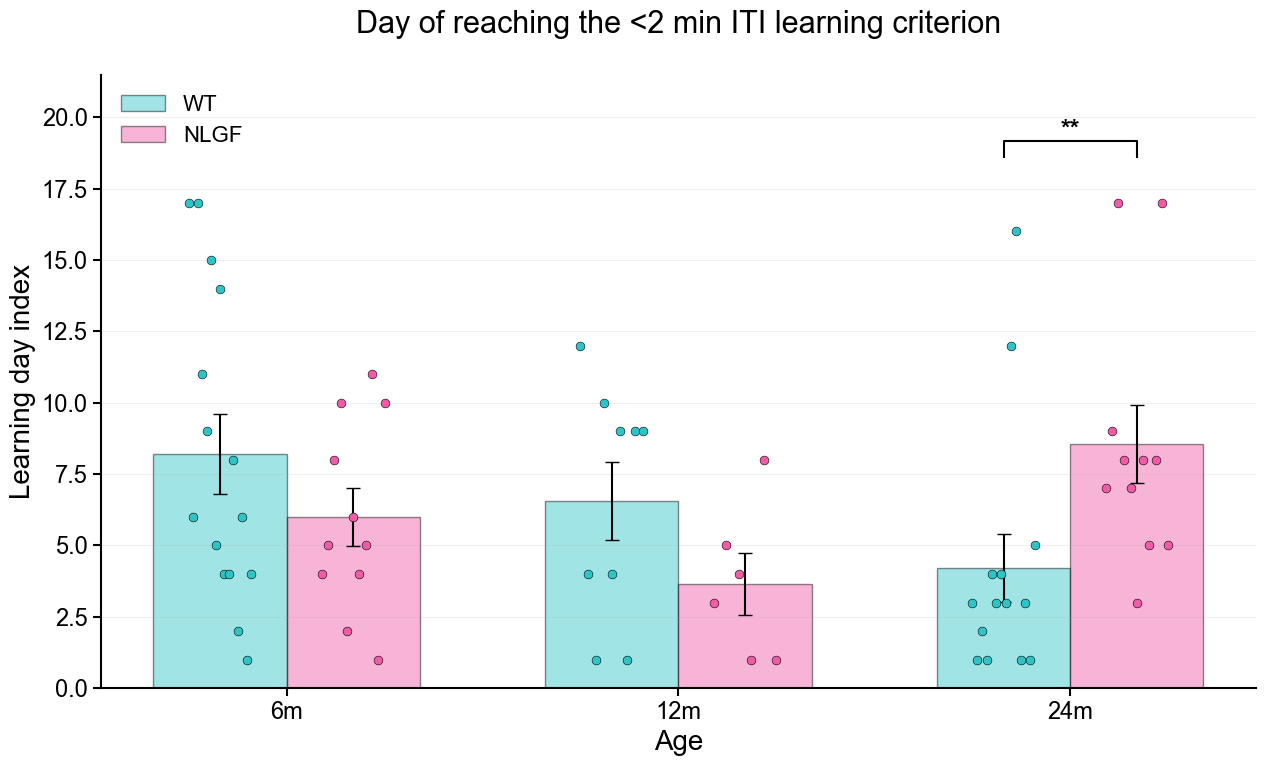

In [3]:
if learning_df.empty:
    print("No learning criterion data were loaded.")
else:
    learning_plot_df = learning_df[
        learning_df["genotype"].isin(GENO_ORDER)
    ].copy()

    if "criterion_met" in learning_plot_df.columns:
        learning_plot_df["criterion_met"] = (
            learning_plot_df["criterion_met"]
            .astype(str)
            .str.lower()
            .isin(["true", "1", "yes"])
        )

        learning_plot_df = learning_plot_df[
            learning_plot_df["criterion_met"]
        ].copy()

    learning_plot_df["learning_day_index"] = pd.to_numeric(
        learning_plot_df["learning_day_index"],
        errors="coerce",
    )

    learning_plot_df = learning_plot_df.dropna(
        subset=["learning_day_index"]
    )

    summary_learning = (
        learning_plot_df
        .groupby(["age", "genotype"], as_index=False)
        .agg(
            mean_learning_day=("learning_day_index", "mean"),
            sem_learning_day=("learning_day_index", safe_sem),
            n_mice=("mouse_global", "nunique"),
        )
    )

    fig, ax = plt.subplots(figsize=(13, 8))

    age_x = np.arange(len(AGE_ORDER))
    width = 0.34

    for genotype_index, genotype in enumerate(GENO_ORDER):
        genotype_summary = (
            summary_learning[
                summary_learning["genotype"] == genotype
            ]
            .set_index("age")
            .reindex(AGE_ORDER)
        )

        offset = (
            genotype_index - (len(GENO_ORDER) - 1) / 2
        ) * width

        x = age_x + offset

        ax.bar(
            x,
            genotype_summary["mean_learning_day"],
            yerr=genotype_summary["sem_learning_day"],
            width=width,
            capsize=5,
            label=genotype,
            color=GENO_COLORS[genotype],
            alpha=0.45,
            edgecolor="black",
        )

        for age_index, age in enumerate(AGE_ORDER):
            vals = learning_plot_df.loc[
                (learning_plot_df["age"] == age)
                & (learning_plot_df["genotype"] == genotype),
                "learning_day_index",
            ].dropna()

            if vals.empty:
                continue

            jitter = np.linspace(-0.08, 0.08, len(vals))
            ax.scatter(
                np.full(len(vals), x[age_index]) + jitter,
                vals,
                color=GENO_COLORS[genotype],
                edgecolor="black",
                linewidth=0.4,
                s=40,
                zorder=3,
            )

    # RAW, unadjusted WT-vs-NLGF significance within each age
    from scipy.stats import shapiro, ttest_ind, mannwhitneyu
    allvals = pd.to_numeric(learning_plot_df["learning_day_index"],errors="coerce").dropna()
    span = max(allvals.max()-allvals.min(), 1)
    ystar = allvals.max() + 0.10*span
    for ai, age in enumerate(AGE_ORDER):
        wt = learning_plot_df.loc[(learning_plot_df["age"]==age)&(learning_plot_df["genotype"]=="WT"),"learning_day_index"].dropna()
        ng = learning_plot_df.loc[(learning_plot_df["age"]==age)&(learning_plot_df["genotype"]=="NLGF"),"learning_day_index"].dropna()
        if len(wt)<2 or len(ng)<2: continue
        pw = shapiro(wt).pvalue if len(wt)>=3 else 0
        pn = shapiro(ng).pvalue if len(ng)>=3 else 0
        if pw>0.05 and pn>0.05:
            p = ttest_ind(wt,ng,equal_var=False).pvalue
        else:
            p = mannwhitneyu(wt,ng,alternative="two-sided").pvalue
        st = "****" if p<0.0001 else "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
        if st:
            x1=ai-width/2; x2=ai+width/2; h=0.035*span
            ax.plot([x1,x1,x2,x2],[ystar,ystar+h,ystar+h,ystar],color="black",lw=1.5,clip_on=False)
            ax.text(ai,ystar+h,st,ha="center",va="bottom",fontsize=18,fontweight="bold",clip_on=False)
    ax.set_ylim(ax.get_ylim()[0], max(ax.get_ylim()[1], ystar+0.18*span))

    ax.set_xticks(age_x)
    ax.set_xticklabels(AGE_ORDER)
    ax.set_xlabel("Age")
    ax.set_ylabel("Learning day index")
    ax.set_title(
        "Day of reaching the <2 min ITI learning criterion\n"
    )
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR / "MASTER_average_learning_day_by_age_genotype.pdf",
        bbox_inches="tight",
        transparent=True,
    )
    plt.show()

    summary_learning.to_csv(
        OUTPUT_DIR / "MASTER_average_learning_day_summary.csv",
        index=False,
    )


## Individual learning days across combined cohorts

This figure keeps every mouse visible after cohorts are combined within age.

- Rows = age
- Columns = genotype
- Circles = mice that reached criterion

Mouse labels include the cohort so repeated kage numbers remain distinguishable.

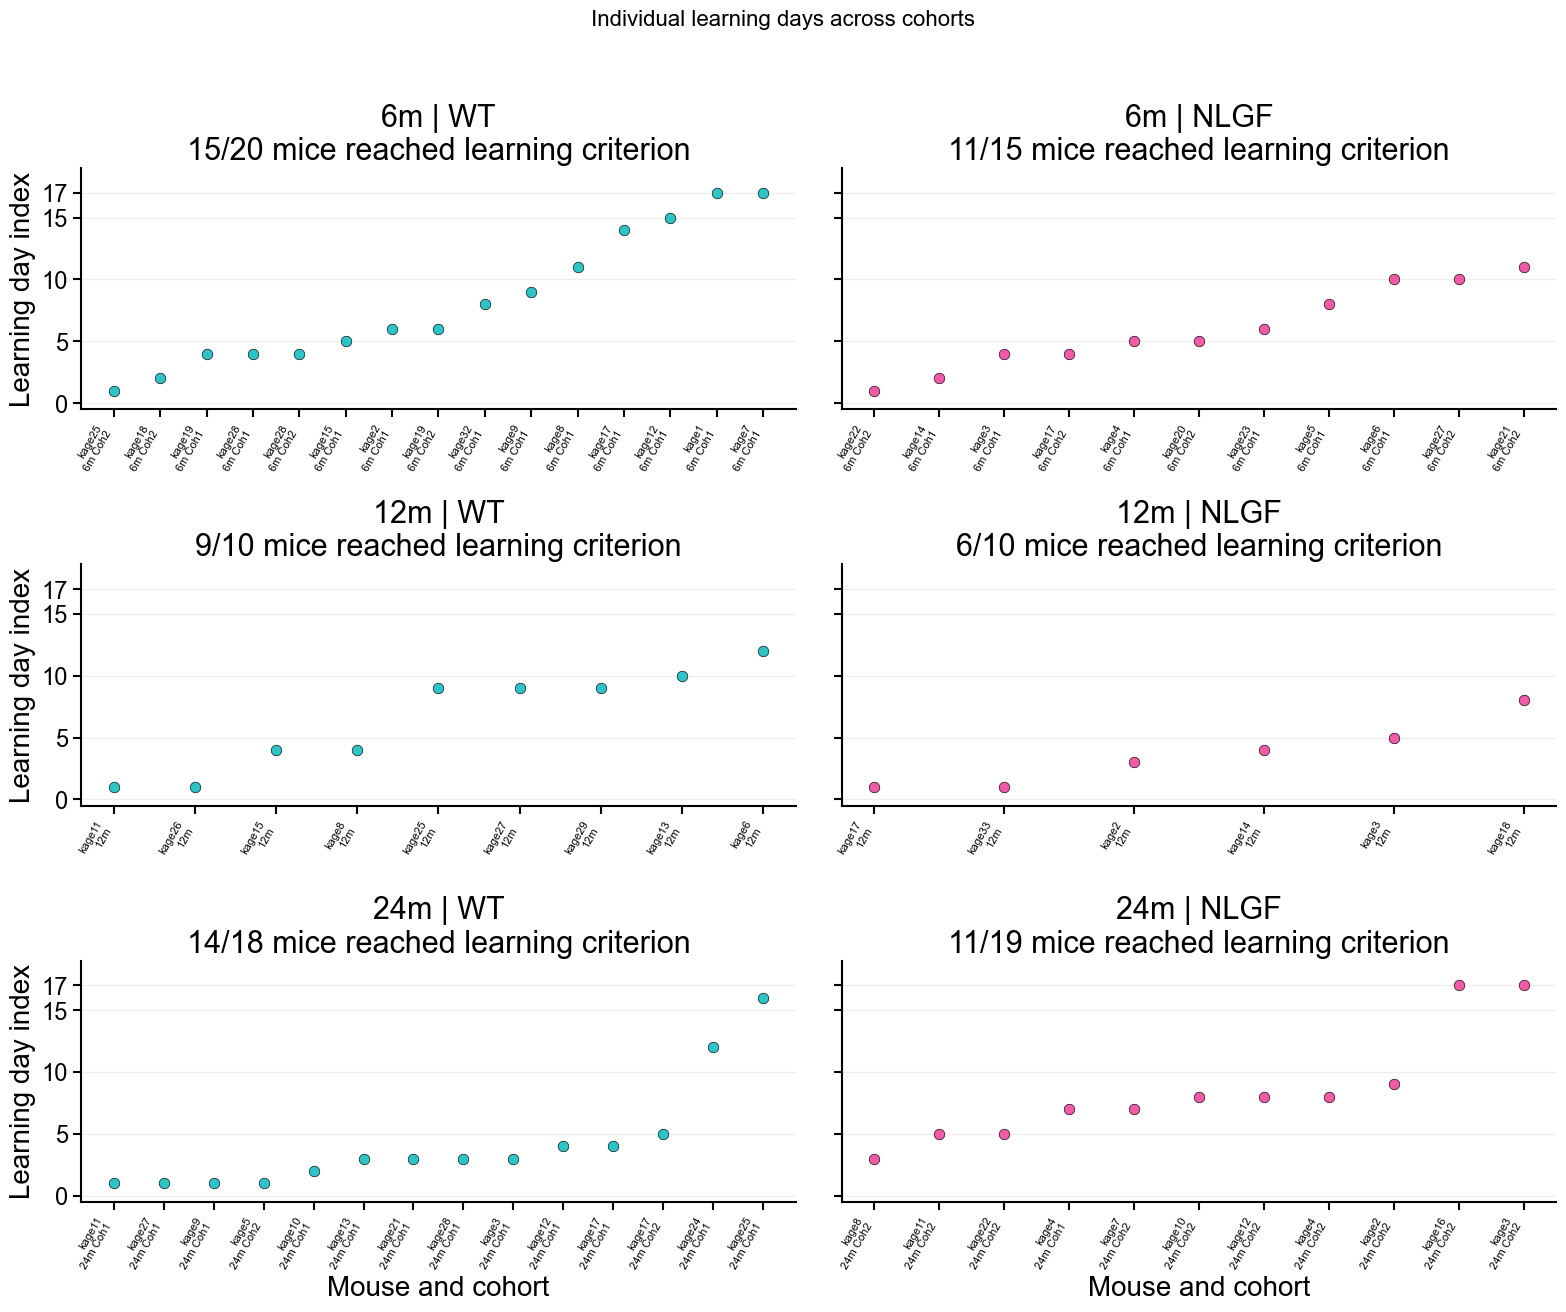

In [4]:
if learning_df.empty:
    print("No learning criterion data were loaded.")

else:
    individual_learning = learning_df[
        learning_df["genotype"].isin(GENO_ORDER)
        & learning_df["age"].isin(AGE_ORDER)
    ].copy()

    individual_learning["criterion_met"] = (
        individual_learning["criterion_met"]
        .astype(str)
        .str.lower()
        .isin(["true", "1", "yes"])
    )

    individual_learning["learning_day_index"] = pd.to_numeric(
        individual_learning["learning_day_index"],
        errors="coerce",
    )

    # Keep only mice that reached the learning criterion
    individual_learning = individual_learning[
        individual_learning["criterion_met"]
        & individual_learning["learning_day_index"].notna()
    ].copy()

    max_observed_day = int(
        individual_learning["learning_day_index"].max()
    )

    fig, axes = plt.subplots(
        len(AGE_ORDER),
        len(GENO_ORDER),
        figsize=(16, 13),
        sharey=True,
    )

    all_learning = learning_df[
        learning_df["genotype"].isin(GENO_ORDER)
        & learning_df["age"].isin(AGE_ORDER)
    ].copy()

    all_learning["criterion_met"] = (
        all_learning["criterion_met"]
        .astype(str)
        .str.lower()
        .isin(["true", "1", "yes"])
    )

    for row, age in enumerate(AGE_ORDER):
        for col, genotype in enumerate(GENO_ORDER):
            ax = axes[row, col]

            panel = individual_learning[
                (individual_learning["age"] == age)
                & (individual_learning["genotype"] == genotype)
            ].copy()

            panel = panel.sort_values(
                ["learning_day_index", "mouse_global"]
            )

            n_total = len(
                all_learning[
                    (all_learning["age"] == age)
                    & (all_learning["genotype"] == genotype)
                ]
            )

            n_reached = len(panel)

            if panel.empty:
                ax.text(
                    0.5,
                    0.5,
                    "No mice reached criterion",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_title(f"{age} | {genotype}")
                continue

            x = np.arange(len(panel))

            ax.scatter(
                x,
                panel["learning_day_index"],
                s=58,
                color=GENO_COLORS[genotype],
                edgecolor="black",
                linewidth=0.45,
                zorder=3,
            )

            labels = [
                f"{mouse}\n{cohort}"
                for mouse, cohort in zip(
                    panel["mouse"],
                    panel["cohort"],
                )
            ]

            ax.set_xticks(x)
            ax.set_xticklabels(
                labels,
                rotation=60,
                ha="right",
                fontsize=8,
            )

            ax.set_title(
                f"{age} | {genotype}\n"
                f"{n_reached}/{n_total} mice reached learning criterion"
            )

            ax.grid(axis="y", alpha=0.22)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            if col == 0:
                ax.set_ylabel("Learning day index")

            if row == len(AGE_ORDER) - 1:
                ax.set_xlabel("Mouse and cohort")

    y_ticks = list(range(0, max_observed_day + 1, 5))

    if not y_ticks or y_ticks[-1] != max_observed_day:
        y_ticks.append(max_observed_day)

    for ax in axes.flat:
        ax.set_ylim(-0.5, max_observed_day + 2)
        ax.set_yticks(y_ticks)

    fig.suptitle(
        "Individual learning days across cohorts",
        fontsize=16,
        y=1.015,
    )

    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR
        / "MASTER_individual_learning_days_reached_only.pdf",
        bbox_inches="tight",
        transparent=True,
    )

    plt.show()

    individual_learning.to_csv(
        OUTPUT_DIR
        / "MASTER_individual_learning_days_reached_only.csv",
        index=False,
    )

## 2. Cumulative learning curves by age and genotype

Each age has one panel.

WT and NLGF are shown on the same axes.

The denominator is all mice available for that age and genotype, including mice that did not reach criterion.

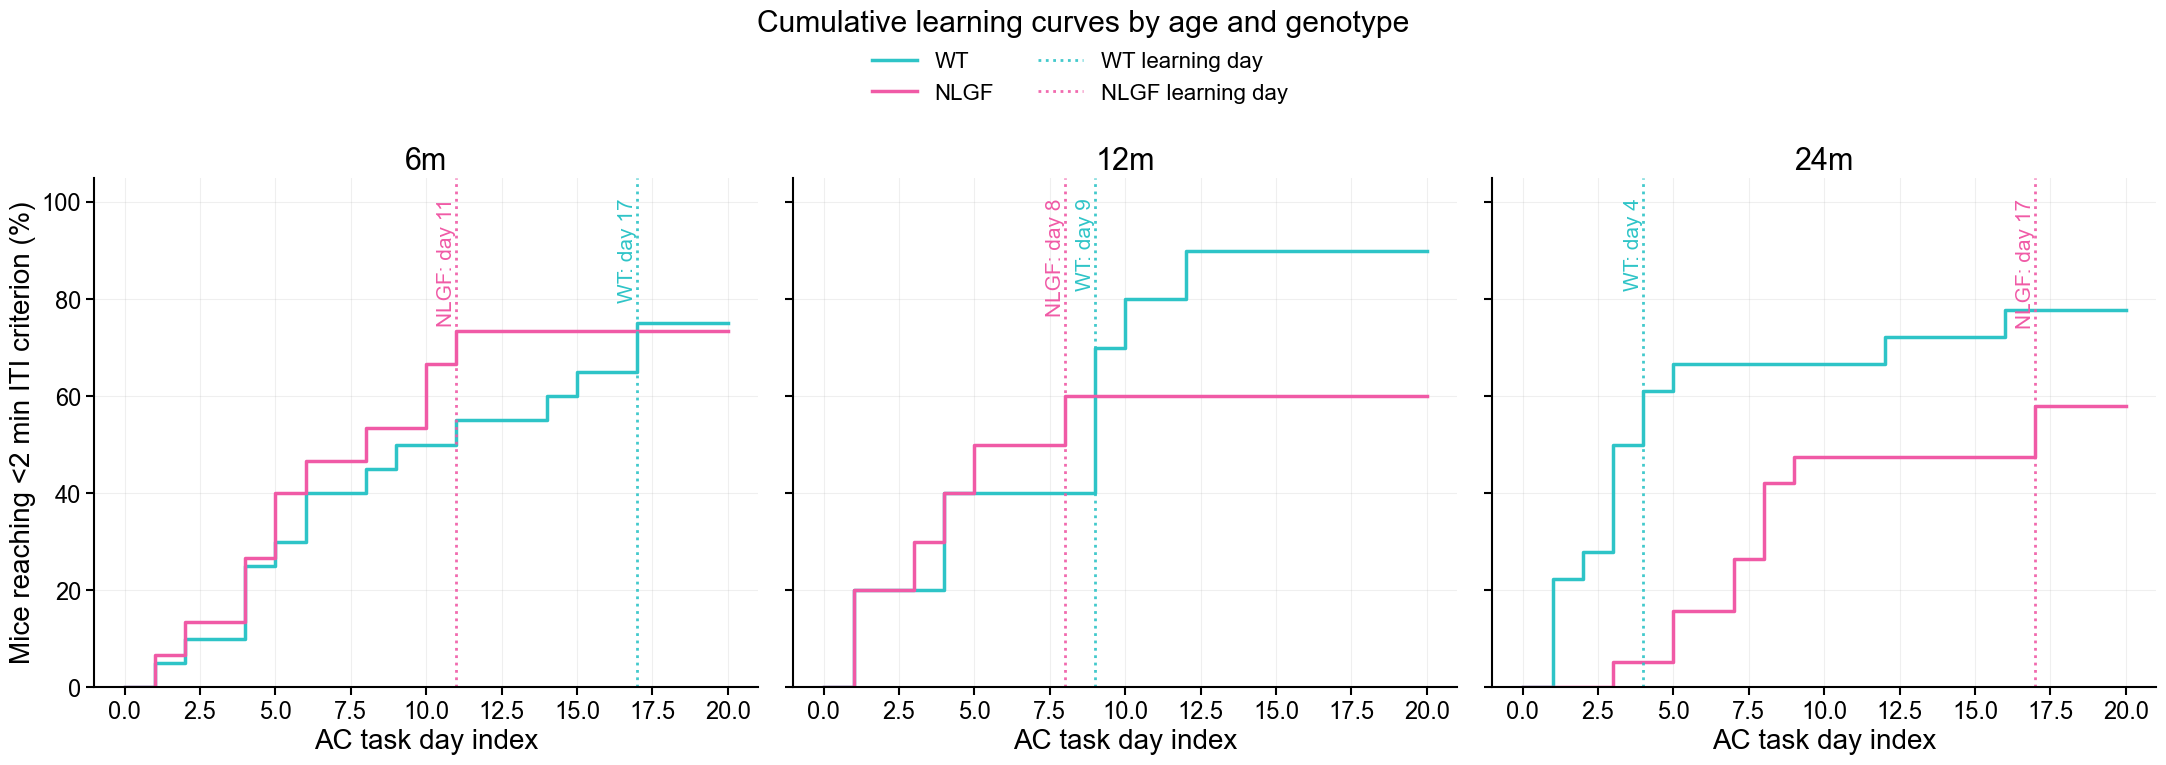

In [33]:
if learning_df.empty:
    print("No learning criterion data were loaded.")
else:
    cumulative_df = learning_df[
        learning_df["genotype"].isin(GENO_ORDER)
    ].copy()

    cumulative_df["criterion_met"] = (
        cumulative_df["criterion_met"]
        .astype(str)
        .str.lower()
        .isin(["true", "1", "yes"])
    )

    cumulative_df["learning_day_index"] = pd.to_numeric(
        cumulative_df["learning_day_index"],
        errors="coerce",
    )

    fig, axes = plt.subplots(
        1,
        len(AGE_ORDER),
        figsize=(22, 7.5),
        sharey=True,
    )

    for ax, age in zip(axes, AGE_ORDER):
        age_df = cumulative_df[
            cumulative_df["age"] == age
        ].copy()

        # Store each genotype's cumulative curve
        genotype_curves = {}
        genotype_plateaus = {}

        for genotype in GENO_ORDER:
            genotype_df = age_df[
                age_df["genotype"] == genotype
            ].copy()

            if genotype_df.empty:
                continue

            max_day = int(
                max(
                    genotype_df["n_AC_days"].max(),
                    genotype_df["learning_day_index"].max(
                        skipna=True
                    )
                    if genotype_df["learning_day_index"].notna().any()
                    else 0,
                )
            )

            day_values = np.arange(max_day + 1)

            reached = np.array([
                100 * np.mean(
                    genotype_df["criterion_met"]
                    & (
                        genotype_df["learning_day_index"]
                        <= day
                    )
                )
                for day in day_values
            ])

            genotype_curves[genotype] = {
                "days": day_values,
                "reached": reached,
            }

            # Final percentage of mice that reached criterion
            genotype_plateaus[genotype] = reached[-1]

            ax.step(
                day_values,
                reached,
                where="post",
                linewidth=2.5,
                color=GENO_COLORS[genotype],
                label=genotype,
            )

        # ----------------------------------------------------------
        # Equivalent group-level learning criterion
        # ----------------------------------------------------------
        if genotype_plateaus:
            # Use the lower final plateau as the common target
            common_target = min(genotype_plateaus.values())

        

            for genotype in GENO_ORDER:
                if genotype not in genotype_curves:
                    continue

                days = genotype_curves[genotype]["days"]
                reached = genotype_curves[genotype]["reached"]

                # First day this genotype reaches the common target
                target_indices = np.where(
                   reached >= common_target
                )[0]

                if len(target_indices) == 0:
                    continue

                group_learning_day = int(
                    days[target_indices[0]]
                )

                ax.axvline(
                    group_learning_day,
                    color=GENO_COLORS[genotype],
                    linestyle=":",
                    linewidth=2,
                    alpha=0.9,
                    label=(
                        f"{genotype} learning day "
                    ),
                )

                # Optional annotation near the top
                ax.text(
                    group_learning_day,
                    102,
                    f"{genotype}: day {group_learning_day} ",
                    color=GENO_COLORS[genotype],
                    rotation=90,
                    va="top",
                    ha="right",
                    fontsize=15,
                )

        ax.set_title(age)
        ax.set_xlabel("AC task day index")
        ax.set_ylim(0, 105)
        ax.grid(alpha=0.2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Mice reaching <2 min ITI criterion (%)")
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=2,
        frameon=False,
    )
    fig.suptitle(
        "Cumulative learning curves by age and genotype\n",
        y=1.03,
    )
    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR / "MASTER_cumulative_learning_by_age_genotype.pdf",
        bbox_inches="tight",
        transparent=True,
    )
    plt.show()


## 3. Longitudinal T-maze performance

2-day moving average is used.

Figure layout:

- rows = age
- columns = genotype
- line colour = ITI bin

Only bins up to 4–6 min are shown.

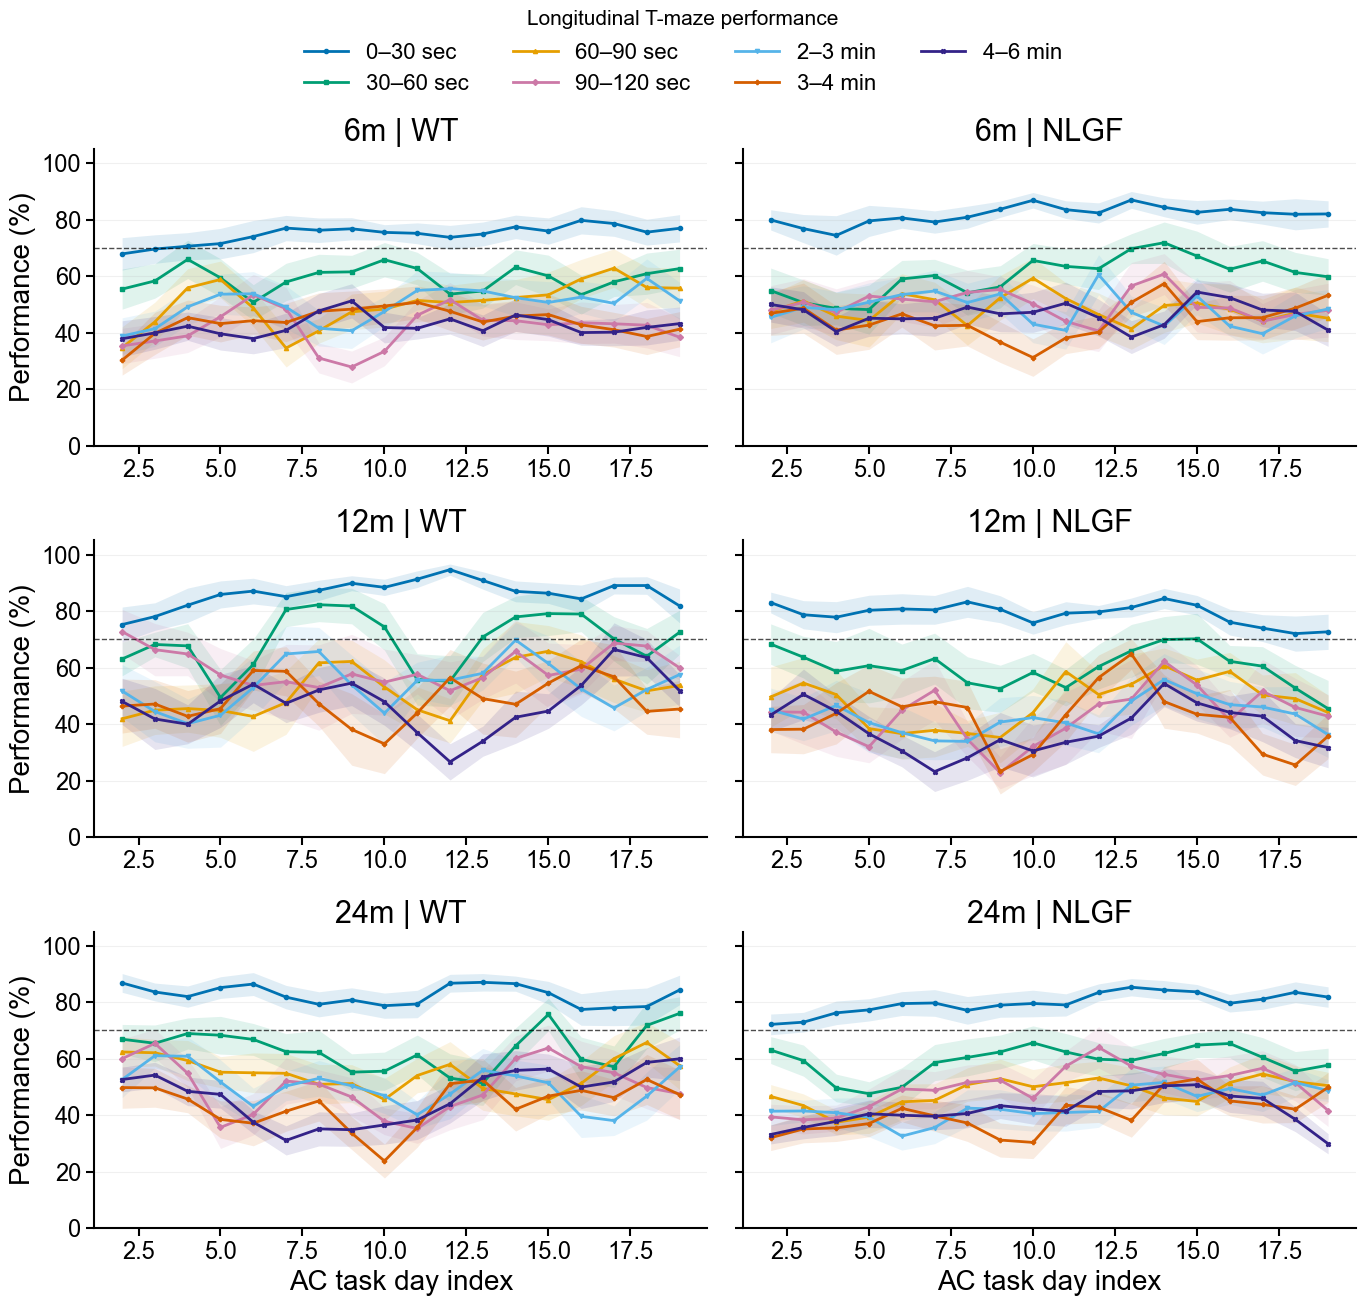

In [32]:
if longitudinal_df.empty:
    print("No longitudinal data were loaded.")
else:
    long_df = longitudinal_df[
        longitudinal_df["genotype"].isin(GENO_ORDER)
        & longitudinal_df["ITI_bin"].isin(LONGITUDINAL_ITI_ORDER)
        & pd.to_numeric(longitudinal_df["day_index"], errors="coerce").lt(20)
    ].copy()

    ma_settings = {
        2: ("performance_2day_percent", 2),
    }

    for ma_days, (value_col, start_day) in ma_settings.items():
        if value_col not in long_df.columns:
            print(f"Missing column: {value_col}")
            continue

        ma_df = long_df[
            long_df["day_index"].ge(start_day)
        ].copy()

        summary_long = (
            ma_df
            .groupby(
                ["age", "genotype", "ITI_bin", "day_index"],
                observed=True,
                as_index=False,
            )
            .agg(
                mean_performance=(value_col, "mean"),
                sem_performance=(value_col, safe_sem),
                n_mice=("mouse_global", "nunique"),
            )
        )

        fig, axes = plt.subplots(
            len(AGE_ORDER),
            len(GENO_ORDER),
            figsize=(14, 13),
            sharex=False,
            sharey=True,
        )

        for row, age in enumerate(AGE_ORDER):
            for col, genotype in enumerate(GENO_ORDER):
                ax = axes[row, col]

                panel = summary_long[
                    (summary_long["age"] == age)
                    & (summary_long["genotype"] == genotype)
                ]

                for iti_label in LONGITUDINAL_ITI_ORDER:
                    group = panel[
                        panel["ITI_bin"] == iti_label
                    ].sort_values("day_index")

                    if group.empty:
                        continue

                    x = group["day_index"].to_numpy(dtype=float)
                    y = group["mean_performance"].to_numpy(dtype=float)
                    error = group["sem_performance"].to_numpy(dtype=float)

                    valid = np.isfinite(x) & np.isfinite(y)

                    ax.plot(
                        x[valid],
                        y[valid],
                        color=ITI_COLORS[iti_label],
                        marker=ITI_MARKERS[iti_label],
                        markersize=3,
                        linewidth=2,
                        label=iti_label,
                    )

                    sem_valid = valid & np.isfinite(error)
                    if sem_valid.any():
                        ax.fill_between(
                            x[sem_valid],
                            (y - error)[sem_valid],
                            (y + error)[sem_valid],
                            color=ITI_COLORS[iti_label],
                            alpha=0.12,
                            linewidth=0,
                        )

                ax.axhline(
                    LEARNING_THRESHOLD_PERCENT,
                    color="black",
                    linestyle="--",
                    linewidth=1,
                    alpha=0.7,
                )

                ax.set_ylim(0, 105)
                ax.set_title(f"{age} | {genotype}")
                ax.grid(axis="y", alpha=0.18)
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)

                if col == 0:
                    ax.set_ylabel("Performance (%)")

                if row == len(AGE_ORDER) - 1:
                    ax.set_xlabel(
                        f"AC task day index"
                    )

        handles, labels = axes[0, 0].get_legend_handles_labels()

        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.0),
            ncol=4,
            frameon=False,
        )
        fig.suptitle(
            f"Longitudinal T-maze performance\n",
            y=1.01,
            fontsize=15,
        )
        fig.tight_layout()

        fig.savefig(
            OUTPUT_DIR
            / f"MASTER_longitudinal_{ma_days}day_MA_by_age_genotype.pdf",
            bbox_inches="tight",
            transparent=True,
        )
        plt.show()

        summary_long.to_csv(
            OUTPUT_DIR
            / f"MASTER_longitudinal_{ma_days}day_MA_summary.csv",
            index=False,
        )


## 4. Performance during the 3 days after learning

Each mouse is aligned to its own individual learning day.

The input CSV already contains one value per mouse and ITI bin averaged across days +1, +2 and +3.

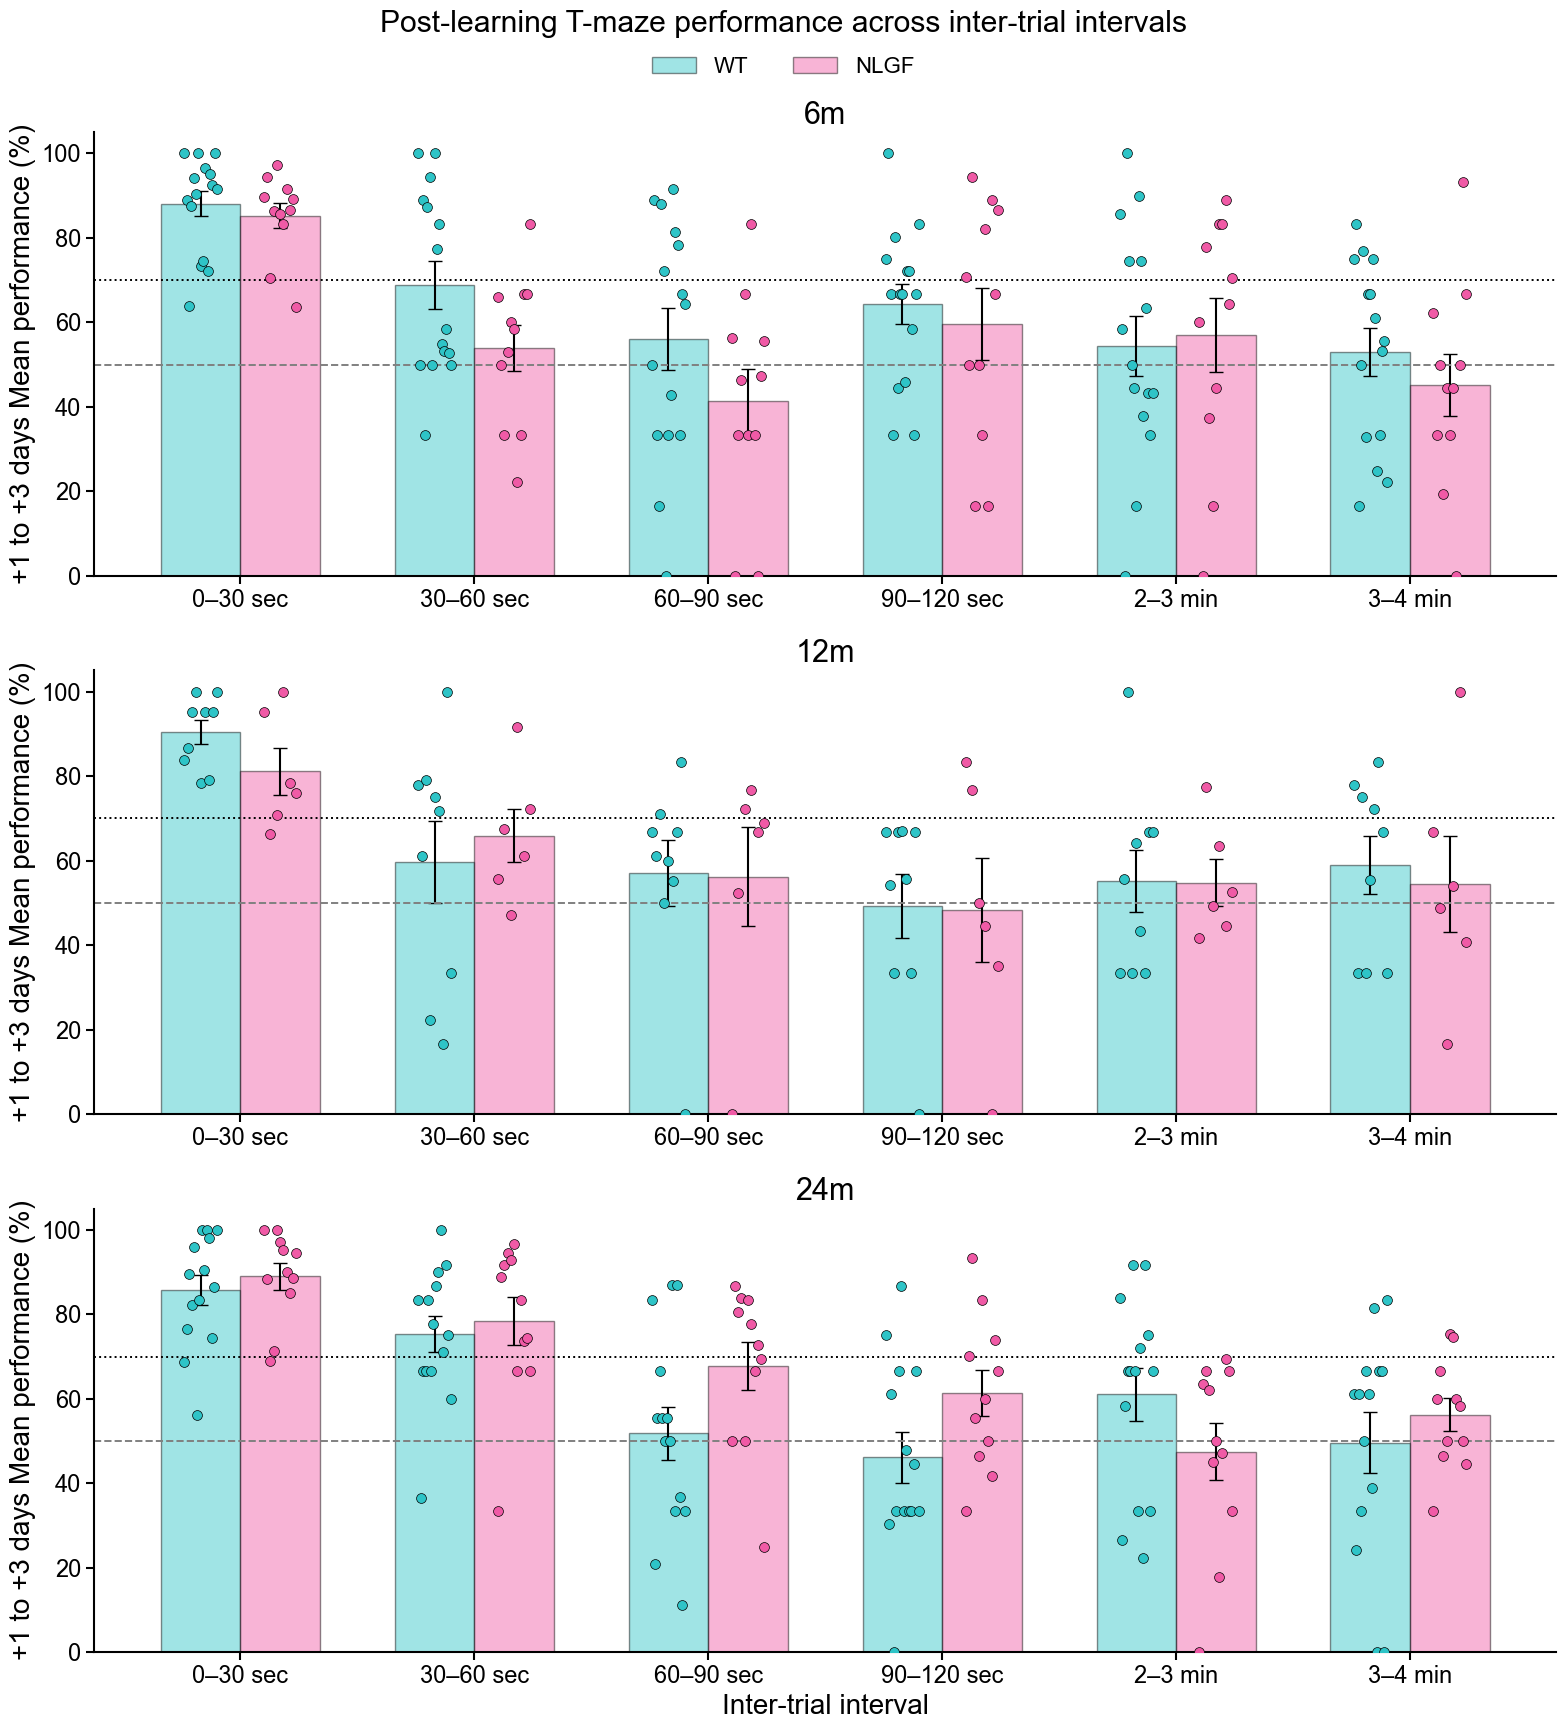

In [41]:
POST_BINS = [
    "0–30 sec","30–60 sec","60–90 sec","90–120 sec","2–3 min","3–4 min",
]

fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharey=True)
axes = np.asarray(axes).reshape(-1)
iti_x = np.arange(len(POST_BINS))
width = 0.34

for ax, age in zip(axes, AGE_ORDER):
    age_summary = summary_post[summary_post["age"] == age]

    for genotype_index, genotype in enumerate(GENO_ORDER):
        group=(age_summary[age_summary["genotype"]==genotype]
               .set_index("ITI_bin").reindex(POST_BINS))
        offset=(genotype_index-(len(GENO_ORDER)-1)/2)*width
        x=iti_x+offset
        ax.bar(x,group["mean_performance"],yerr=group["sem_performance"],
               width=width,capsize=5,color=GENO_COLORS[genotype],alpha=0.45,
               edgecolor="black",label=genotype)
        for ii,iti_label in enumerate(POST_BINS):
            vals=post_df.loc[
                (post_df["age"]==age)&(post_df["genotype"]==genotype)&
                (post_df["ITI_bin"]==iti_label), value_col].dropna()
            if vals.empty: continue
            jitter=np.linspace(-0.07,0.07,len(vals))
            ax.scatter(np.full(len(vals),x[ii])+jitter,vals,
                       color=GENO_COLORS[genotype],edgecolor="black",
                       linewidth=0.5,s=50,zorder=3)

    # RAW p-value stars only
    from scipy.stats import shapiro, ttest_ind, mannwhitneyu
    for ii,iti_label in enumerate(POST_BINS):
        wt=post_df.loc[(post_df["age"]==age)&(post_df["genotype"]=="WT")&(post_df["ITI_bin"]==iti_label),value_col].dropna()
        ng=post_df.loc[(post_df["age"]==age)&(post_df["genotype"]=="NLGF")&(post_df["ITI_bin"]==iti_label),value_col].dropna()
        if len(wt)<2 or len(ng)<2: continue
        pw=shapiro(wt).pvalue if len(wt)>=3 else 0
        pn=shapiro(ng).pvalue if len(ng)>=3 else 0
        p=ttest_ind(wt,ng,equal_var=False).pvalue if (pw>0.05 and pn>0.05) else mannwhitneyu(wt,ng,alternative="two-sided").pvalue
        st="****" if p<0.0001 else "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
        if st:
            ymax=max(wt.max(),ng.max()); h=2.0
            ax.plot([ii-width/2,ii-width/2,ii+width/2,ii+width/2],
                    [ymax+3,ymax+3+h,ymax+3+h,ymax+3],color="black",lw=1.5,clip_on=False)
            ax.text(ii,ymax+3+h,st,ha="center",va="bottom",fontsize=18,fontweight="bold")

    ax.axhline(50,color="gray",linestyle="--",linewidth=1.4)
    ax.axhline(LEARNING_THRESHOLD_PERCENT,color="black",linestyle=":",linewidth=1.4)
    ax.set_xticks(iti_x); ax.set_xticklabels(POST_BINS)
    ax.set_title(f"{age}")
    ax.set_ylabel("+1 to +3 days Mean performance (%)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Inter-trial interval")
handles,labels=axes[0].get_legend_handles_labels()
fig.legend(dict(zip(labels,handles)).values(),dict(zip(labels,handles)).keys(),
           loc="upper center",bbox_to_anchor=(0.5,0.95),ncol=2,frameon=False)
fig.suptitle("Post-learning T-maze performance across inter-trial intervals",y=0.965)
fig.tight_layout(rect=[0,0,1,0.96])
fig.savefig(OUTPUT_DIR/"THESIS_three_days_after_learning_by_age.pdf",
            bbox_inches="tight",transparent=True)
plt.show()


## 5. Performance versus ITI

Each age has one panel.

WT and NLGF mean ± SEM are calculated across individual mice from both cohorts where applicable.

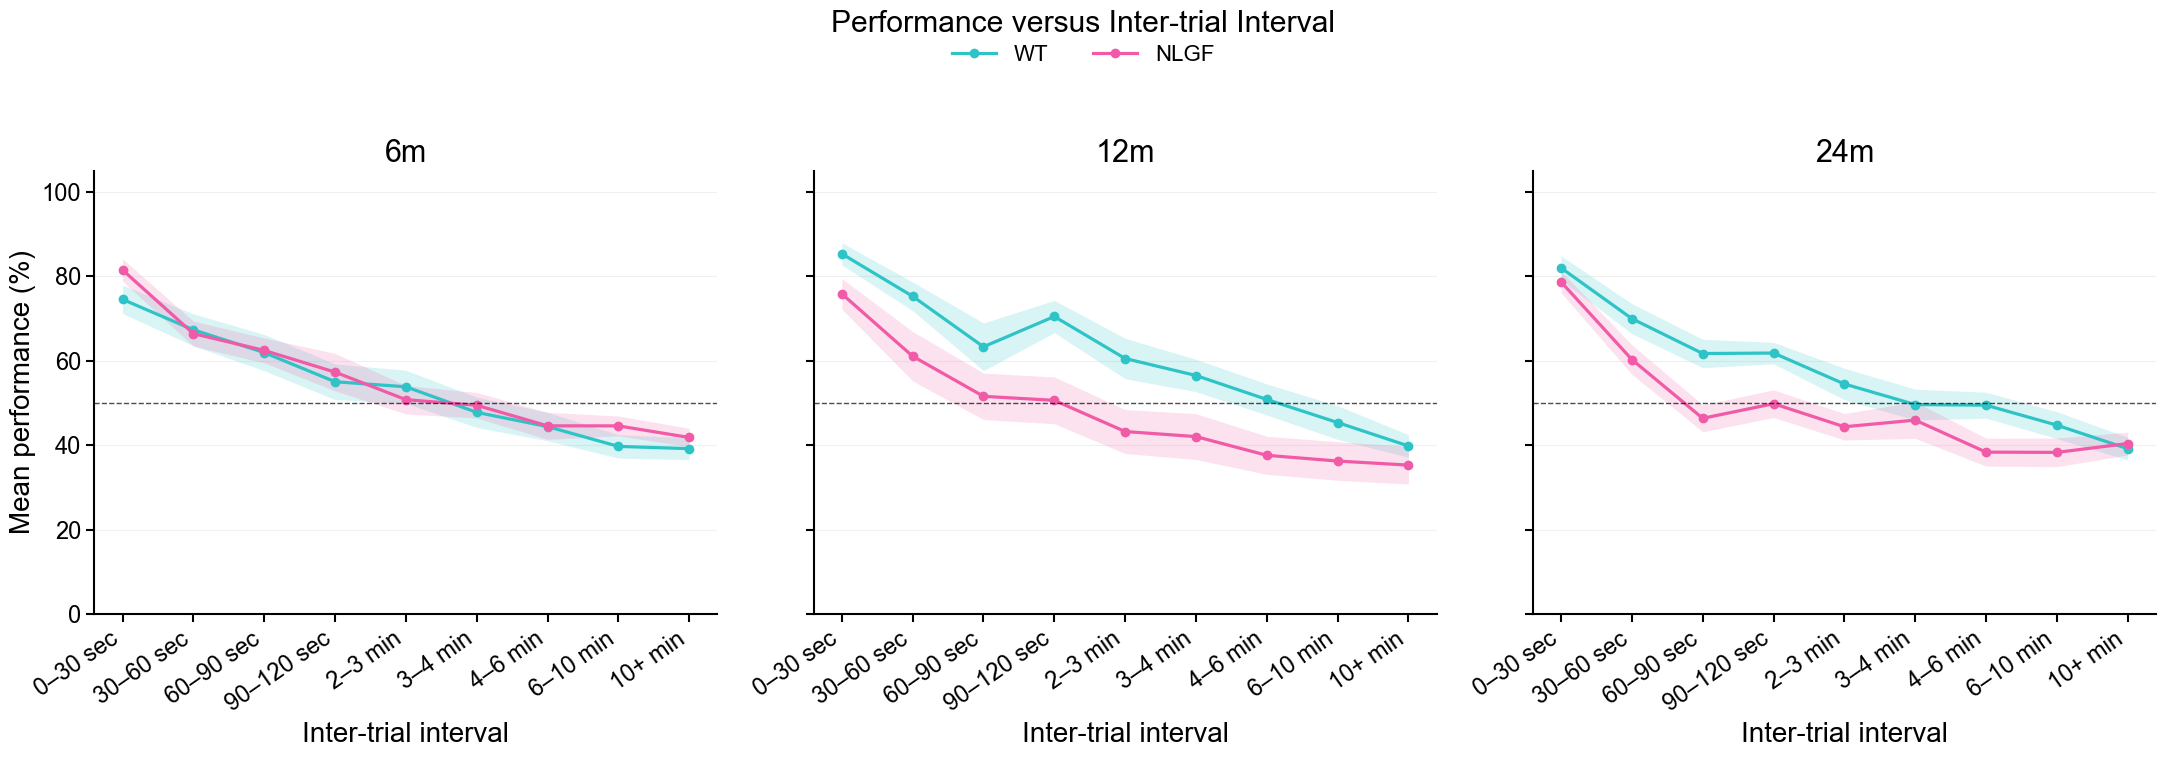

In [30]:
if iti_df.empty:
    print("No performance-vs-ITI data were loaded.")
else:
    iti_plot_df = iti_df[
        iti_df["genotype"].isin(GENO_ORDER)
    ].copy()

    iti_plot_df["ITI_bin"] = pd.Categorical(
        iti_plot_df["ITI_bin"],
        categories=ITI_ORDER,
        ordered=True,
    )

    summary_iti = (
        iti_plot_df
        .groupby(
            ["age", "genotype", "ITI_bin"],
            observed=True,
            as_index=False,
        )
        .agg(
            mean_performance=("performance_percent", "mean"),
            sem_performance=("performance_percent", safe_sem),
            n_mice=("mouse_global", "nunique"),
        )
    )

    fig, axes = plt.subplots(
        1,
        len(AGE_ORDER),
        figsize=(22, 7.5),
        sharey=True,
    )

    x = np.arange(len(ITI_ORDER))

    for ax, age in zip(axes, AGE_ORDER):
        age_summary = summary_iti[
            summary_iti["age"] == age
        ]

        for genotype in GENO_ORDER:
            group = (
                age_summary[
                    age_summary["genotype"] == genotype
                ]
                .set_index("ITI_bin")
                .reindex(ITI_ORDER)
            )

            y = group["mean_performance"].to_numpy(dtype=float)
            error = group["sem_performance"].to_numpy(dtype=float)

            valid = np.isfinite(y)

            ax.plot(
                x[valid],
                y[valid],
                color=GENO_COLORS[genotype],
                marker="o",
                linewidth=2.3,
                label=genotype,
            )

            sem_valid = valid & np.isfinite(error)
            if sem_valid.any():
                ax.fill_between(
                    x[sem_valid],
                    (y - error)[sem_valid],
                    (y + error)[sem_valid],
                    color=GENO_COLORS[genotype],
                    alpha=0.18,
                    linewidth=0,
                )

        ax.axhline(
            50,
            color="black",
            linestyle="--",
            linewidth=1,
            alpha=0.7,
        )
        ax.set_xticks(x)
        ax.set_xticklabels(
            ITI_ORDER,
            rotation=35,
            ha="right",
        )
        ax.set_title(age)
        ax.set_xlabel("Inter-trial interval")
        ax.set_ylim(0, 105)
        ax.grid(axis="y", alpha=0.18)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Mean performance (%)")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=2,
        frameon=False,
    )
    fig.suptitle(
        "Performance versus Inter-trial Interval\n",
        y=1.02,
    )
    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR / "MASTER_performance_vs_ITI.pdf",
        bbox_inches="tight",
        transparent=True,
    )
    plt.show()

    summary_iti.to_csv(
        OUTPUT_DIR / "MASTER_performance_vs_ITI_summary.csv",
        index=False,
    )


## Combined data exports

These files contain all mouse-level data used in the master analysis.

In [10]:
if not learning_df.empty:
    learning_df.to_csv(
        OUTPUT_DIR / "MASTER_all_learning_criterion_mice.csv",
        index=False,
    )

if not longitudinal_df.empty:
    longitudinal_df.to_csv(
        OUTPUT_DIR / "MASTER_all_longitudinal_mice.csv",
        index=False,
    )

if not post_learning_df.empty:
    post_learning_df.to_csv(
        OUTPUT_DIR / "MASTER_all_post_learning_mice.csv",
        index=False,
    )

if not iti_df.empty:
    iti_df.to_csv(
        OUTPUT_DIR / "MASTER_all_performance_vs_ITI_mice.csv",
        index=False,
    )

print("Master outputs saved to:")
print(OUTPUT_DIR)


Master outputs saved to:
/Volumes/Aimi_SmrtKg/Tmaze_MASTER_all_cohorts


,age,genotype,ITI_bin,ITI_midpoint_min,mean_performance,sem_performance,n_mice
0,12m,NLGF,0–30 sec,0.25,75.854532,3.611582,10
2,12m,NLGF,30–60 sec,0.75,61.077106,5.847145,10
5,12m,NLGF,60–90 sec,1.25,51.588892,5.503108,10
7,12m,NLGF,90–120 sec,1.75,50.633946,5.534810,10
1,12m,NLGF,2–3 min,2.50,43.252340,5.199534,10
3,12m,NLGF,3–4 min,3.50,42.055107,5.424704,10
4,12m,NLGF,4–6 min,5.00,37.623139,4.504070,10
6,12m,NLGF,6–10 min,8.00,36.268198,4.562158,10
8,12m,WT,0–30 sec,0.25,85.329960,2.616404,10
10,12m,WT,30–60 sec,0.75,75.269766,3.385709,10


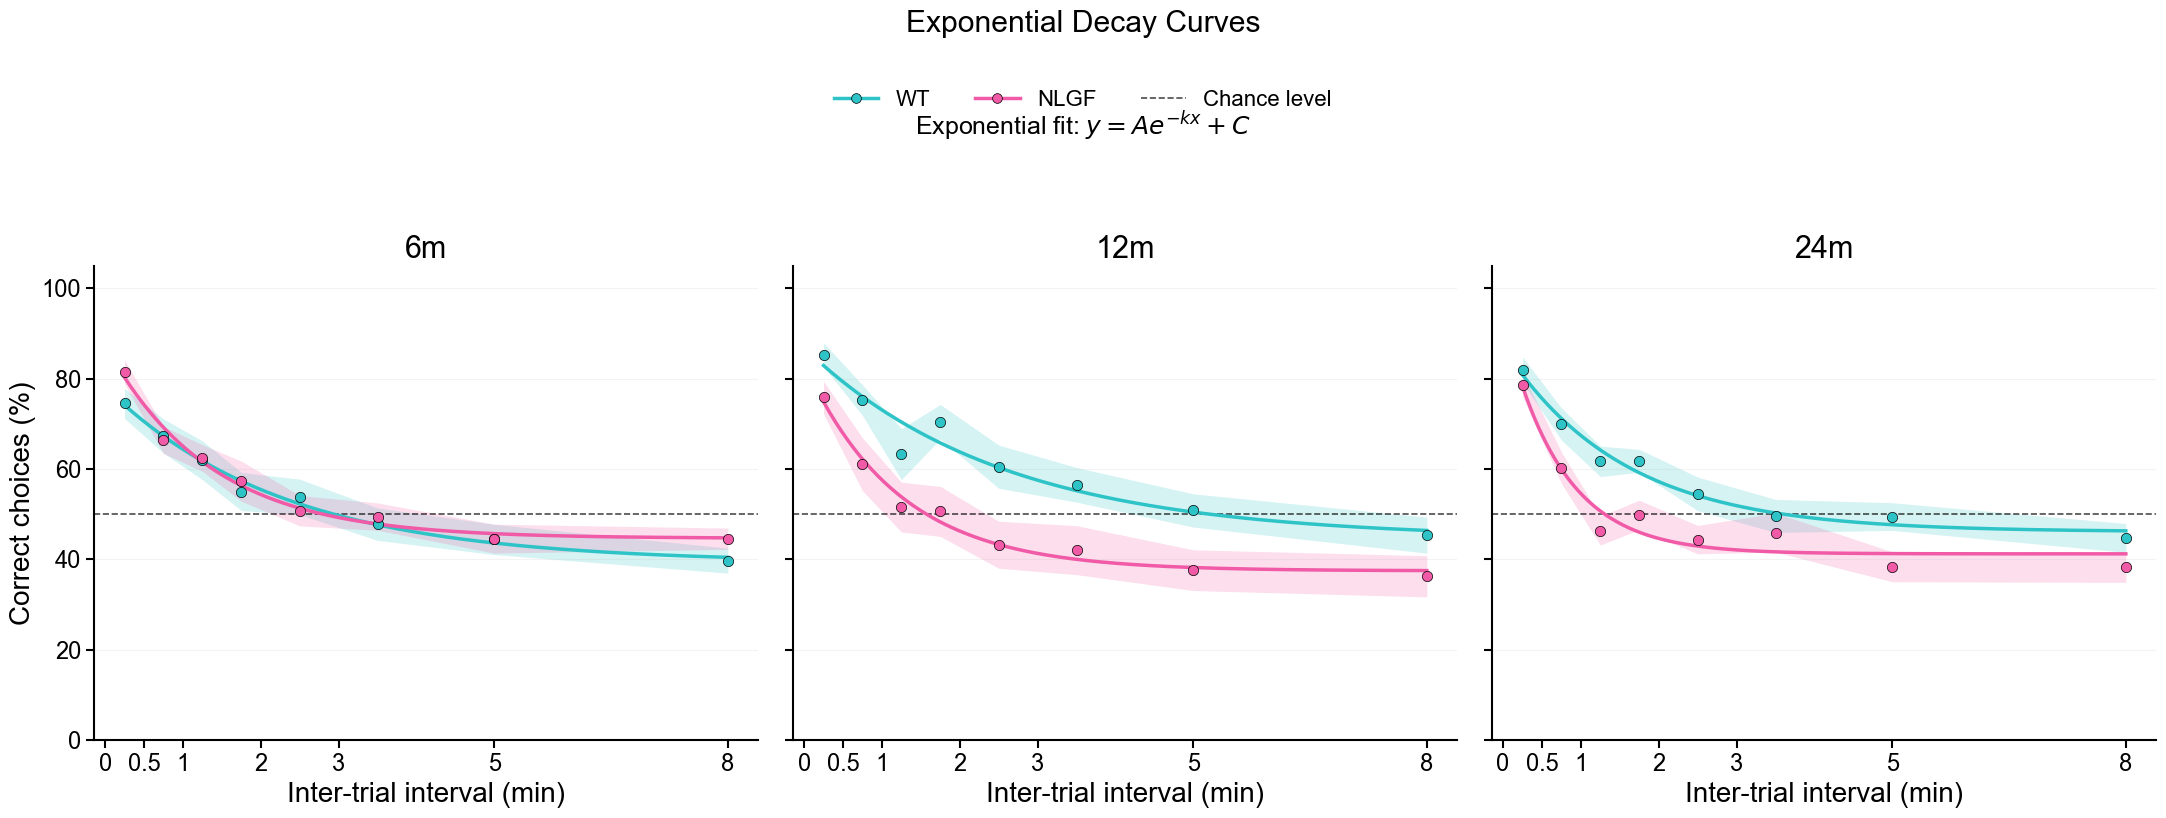

Saved figure to:
/Volumes/Aimi_SmrtKg/Tmaze_MASTER_all_cohorts/MASTER_group_exponential_decay_curves.pdf


,age,genotype,n_mice,n_ITI_bins,A,k,C,tau_exp_min,tau_50_min,r_squared,fit_status
0,6m,WT,20,8,38.902470,0.438830,39.302388,2.278786,2.941998,0.990691,Successful
1,6m,NLGF,15,8,42.913180,0.743951,44.670584,1.344174,2.803863,0.986431,Successful
2,12m,WT,10,8,42.277635,0.395429,44.630994,2.528896,5.218668,0.932309,Successful
3,12m,NLGF,10,8,46.006309,0.826215,37.471881,1.210339,1.574412,0.984846,Successful
4,24m,WT,18,8,40.909945,0.651696,46.109105,1.534459,3.610173,0.979032,Successful
5,24m,NLGF,19,8,52.164407,1.364211,41.235411,0.733024,1.307482,0.943722,Successful


Saved fit results to:
/Volumes/Aimi_SmrtKg/Tmaze_MASTER_all_cohorts/MASTER_group_exponential_decay_fit_results.csv


In [29]:
# ==========================================================
# GROUP EXPONENTIAL DECAY CURVES
# WT vs NLGF within 6m, 12m and 24m
# ==========================================================

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------------------------------------
# Exponential decay equation
# Same equation used in the individual-mouse notebook
# ----------------------------------------------------------
def exp_decay(x, A, k, C):
    x = np.asarray(x, dtype=float)
    return A * np.exp(-k * x) + C


# ----------------------------------------------------------
# Calculate SEM
# ----------------------------------------------------------
def calculate_sem(values):
    values = pd.to_numeric(
        pd.Series(values),
        errors="coerce"
    ).dropna()

    if len(values) <= 1:
        return np.nan

    return values.std(ddof=1) / np.sqrt(len(values))


# ----------------------------------------------------------
# ITI values used for fitting
#
# Use only finite ITI bins.
# The 10+ min bin is excluded because it has no finite midpoint.
# ----------------------------------------------------------
ITI_FIT_ORDER = [
    "0–30 sec",
    "30–60 sec",
    "60–90 sec",
    "90–120 sec",
    "2–3 min",
    "3–4 min",
    "4–6 min",
    "6–10 min",
]

ITI_MIDPOINT_MIN = {
    "0–30 sec": 0.25,
    "30–60 sec": 0.75,
    "60–90 sec": 1.25,
    "90–120 sec": 1.75,
    "2–3 min": 2.5,
    "3–4 min": 3.5,
    "4–6 min": 5.0,
    "6–10 min": 8.0,
}


# ----------------------------------------------------------
# Prepare mouse-level data
# ----------------------------------------------------------
group_decay_df = iti_df[
    iti_df["genotype"].isin(GENO_ORDER)
    & iti_df["age"].isin(AGE_ORDER)
    & iti_df["ITI_bin"].isin(ITI_FIT_ORDER)
].copy()

group_decay_df["performance_percent"] = pd.to_numeric(
    group_decay_df["performance_percent"],
    errors="coerce"
)

group_decay_df["ITI_midpoint_min"] = (
    group_decay_df["ITI_bin"]
    .map(ITI_MIDPOINT_MIN)
    .astype(float)
)

group_decay_df = group_decay_df.dropna(
    subset=[
        "performance_percent",
        "ITI_midpoint_min",
        "mouse_global",
    ]
)


# ----------------------------------------------------------
# Important:
# First calculate one value per mouse per ITI bin.
# This prevents mice with more rows from contributing more weight.
# ----------------------------------------------------------
mouse_decay_df = (
    group_decay_df
    .groupby(
        [
            "age",
            "genotype",
            "mouse_global",
            "ITI_bin",
            "ITI_midpoint_min",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        performance_percent=(
            "performance_percent",
            "mean",
        )
    )
)


# ----------------------------------------------------------
# Calculate group mean and SEM across mice
# ----------------------------------------------------------
group_decay_summary = (
    mouse_decay_df
    .groupby(
        [
            "age",
            "genotype",
            "ITI_bin",
            "ITI_midpoint_min",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        mean_performance=(
            "performance_percent",
            "mean",
        ),
        sem_performance=(
            "performance_percent",
            calculate_sem,
        ),
        n_mice=(
            "mouse_global",
            "nunique",
        ),
    )
    .sort_values(
        [
            "age",
            "genotype",
            "ITI_midpoint_min",
        ]
    )
)

display(group_decay_summary)


# ----------------------------------------------------------
# Fit curves and create figure
# ----------------------------------------------------------
fit_results = []

fig, axes = plt.subplots(
    1,
    len(AGE_ORDER),
    figsize=(22, 7.5),
    sharex=True,
    sharey=True,
)

axes = np.atleast_1d(axes)


for ax, age in zip(axes, AGE_ORDER):

    age_data = group_decay_summary[
        group_decay_summary["age"] == age
    ]

    for genotype in GENO_ORDER:

        group = (
            age_data[
                age_data["genotype"] == genotype
            ]
            .sort_values("ITI_midpoint_min")
            .copy()
        )

        if group.empty:
            continue

        x = group["ITI_midpoint_min"].to_numpy(
            dtype=float
        )

        y = group["mean_performance"].to_numpy(
            dtype=float
        )

        error = group["sem_performance"].to_numpy(
            dtype=float
        )

        valid = np.isfinite(x) & np.isfinite(y)

        x_valid = x[valid]
        y_valid = y[valid]
        error_valid = error[valid]

        # ----------------------------------------------
        # Plot group mean ± SEM
        # ----------------------------------------------
        # Observed group means as points only
        ax.scatter(
            x_valid,
            y_valid,
            s=55,
            color=GENO_COLORS[genotype],
            edgecolor="black",
            linewidth=0.5, zorder=4,
        )


        # Shaded SEM
        ax.fill_between(
            x_valid,
            y_valid - error_valid,
            y_valid + error_valid,
            color=GENO_COLORS[genotype],
            alpha=0.20,
            linewidth=0,
            zorder=1,
        )

        # At least three finite points are required
        if len(x_valid) < 3:

            fit_results.append({
                "age": age,
                "genotype": genotype,
                "n_mice": group["n_mice"].max(),
                "n_ITI_bins": len(x_valid),
                "A": np.nan,
                "k": np.nan,
                "C": np.nan,
                "tau_exp_min": np.nan,
                "tau_50_min": np.nan,
                "r_squared": np.nan,
                "fit_status": "Insufficient data",
            })

            continue

        # ----------------------------------------------
        # Starting values for curve fitting
        # ----------------------------------------------
        A_guess = y_valid[0] - y_valid[-1]
        C_guess = y_valid[-1]
        k_guess = 0.2

        try:

            parameters, covariance = curve_fit(
                exp_decay,
                x_valid,
                y_valid,
                p0=[
                    A_guess,
                    k_guess,
                    C_guess,
                ],
                maxfev=50000,
            )

            A_fit, k_fit, C_fit = parameters

            predicted = exp_decay(
                x_valid,
                A_fit,
                k_fit,
                C_fit,
            )

            r_squared = r2_score(
                y_valid,
                predicted,
            )

            # Exponential time constant
            tau_exp = (
                1 / k_fit
                if np.isfinite(k_fit) and k_fit > 0
                else np.nan
            )

            # Time where fitted curve reaches 50%
            ratio = (
                (50 - C_fit) / A_fit
                if A_fit != 0
                else np.nan
            )

            if (
                np.isfinite(ratio)
                and ratio > 0
                and np.isfinite(k_fit)
                and k_fit > 0
            ):
                tau_50 = -np.log(ratio) / k_fit
            else:
                tau_50 = np.nan

            # ------------------------------------------
            # Smooth fitted line
            # ------------------------------------------
            x_fit = np.linspace(
                x_valid.min(),
                x_valid.max(),
                300,
            )

            y_fit = exp_decay(
                x_fit,
                A_fit,
                k_fit,
                C_fit,
            )

            ax.plot(
                x_fit,
                y_fit,
                color=GENO_COLORS[genotype],
                linewidth=2.5,
                label="_nolegend_",
                zorder=3,
            )

            fit_results.append({
                "age": age,
                "genotype": genotype,
                "n_mice": group["n_mice"].max(),
                "n_ITI_bins": len(x_valid),
                "A": A_fit,
                "k": k_fit,
                "C": C_fit,
                "tau_exp_min": tau_exp,
                "tau_50_min": tau_50,
                "r_squared": r_squared,
                "fit_status": "Successful",
            })

        except Exception as error_message:

            print(
                f"Fit failed for {age} {genotype}: "
                f"{error_message}"
            )

            fit_results.append({
                "age": age,
                "genotype": genotype,
                "n_mice": group["n_mice"].max(),
                "n_ITI_bins": len(x_valid),
                "A": np.nan,
                "k": np.nan,
                "C": np.nan,
                "tau_exp_min": np.nan,
                "tau_50_min": np.nan,
                "r_squared": np.nan,
                "fit_status": f"Failed: {error_message}",
            })


    # Chance performance
    ax.axhline(
        50,
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.7,
        label="Chance level",
    )

    ax.set_title(age)
    ax.set_xlabel("Inter-trial interval (min)")
    ax.set_xticks([0, 0.5, 1, 2, 3, 5, 8])
    ax.set_xticklabels(["0", "0.5", "1", "2", "3", "5", "8"])

    ax.set_ylim(0, 105)
    ax.grid(
        axis="y",
        alpha=0.15,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


axes[0].set_ylabel("Correct choices (%)")


# ----------------------------------------------------------
# One shared legend without duplicate entries
# ----------------------------------------------------------
from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [0],
        [0],
        color=GENO_COLORS["WT"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        markeredgecolor="black",
        markeredgewidth=0.5,
        label="WT",
    ),

    Line2D(
        [0],
        [0],
        color=GENO_COLORS["NLGF"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        markeredgecolor="black",
        markeredgewidth=0.5,
        label="NLGF",
    ),

    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.7,
        label="Chance level",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
)

fig.text(
    0.5,
    0.945,
    r"Exponential fit: $y = A e^{-kx} + C$",
    ha="center",
    va="center",
    fontsize=18,
)

fig.suptitle(
    "Exponential Decay Curves",
    y=1.10,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.91]
)


# ----------------------------------------------------------
# Save PDF
# ----------------------------------------------------------
figure_path = (
    OUTPUT_DIR
    / "MASTER_group_exponential_decay_curves.pdf"
)

fig.savefig(
    figure_path,
    format="pdf",
    bbox_inches="tight",
    transparent=True,
)

plt.show()

print(f"Saved figure to:\n{figure_path}")


# ----------------------------------------------------------
# Save group summary and fitted parameters
# ----------------------------------------------------------
fit_results_df = pd.DataFrame(fit_results)

group_decay_summary.to_csv(
    OUTPUT_DIR
    / "MASTER_group_exponential_decay_mean_SEM.csv",
    index=False,
)

fit_results_df.to_csv(
    OUTPUT_DIR
    / "MASTER_group_exponential_decay_fit_results.csv",
    index=False,
)

display(fit_results_df)

print(
    "Saved fit results to:\n"
    f"{OUTPUT_DIR / 'MASTER_group_exponential_decay_fit_results.csv'}"
)

## Statistical comparison of exponential time constants

This section compares the group exponential time constant, \(\tau = 1/k\), between WT and NLGF mice at each age.

Because each group-level curve produces only one fitted \(\tau\), an ordinary t-test on the six group fits would not be valid. Instead, mice are resampled with replacement within each age and genotype, the group curve is refitted for every bootstrap sample, and the WT–NLGF difference in \(\tau\) is calculated.

Outputs:

- observed group \(\tau\) values
- bootstrap 95% confidence intervals
- WT versus NLGF bootstrap difference
- two-sided bootstrap p-value
- significance label
- CSV and PDF exports


,age,comparison,WT_tau_observed_min,WT_tau_bootstrap_mean_min,WT_tau_bootstrap_CI95_low_min,WT_tau_bootstrap_CI95_high_min,WT_successful_bootstrap_fits,NLGF_tau_observed_min,NLGF_tau_bootstrap_mean_min,NLGF_tau_bootstrap_CI95_low_min,NLGF_tau_bootstrap_CI95_high_min,NLGF_successful_bootstrap_fits,tau_difference_NLGF_minus_WT_min,difference_CI95_low_min,difference_CI95_high_min,bootstrap_p_value_two_sided,significance,bootstrap_iterations_requested
0,6m,WT vs NLGF,2.278783,2.334488,1.542412,3.426311,2000,1.344174,1.384873,0.978490,1.989900,2000,-0.949614,-2.062329,-0.012952,0.047976,*,2000
1,12m,WT vs NLGF,2.528924,2.725026,1.050101,5.479666,2000,1.210338,1.317862,0.747873,2.482521,2000,-1.407164,-4.157565,0.509868,0.162919,ns,2000
2,24m,WT vs NLGF,1.534458,1.574289,1.090144,2.336213,2000,0.733022,0.783473,0.525561,1.361370,2000,-0.790816,-1.598181,-0.079328,0.037981,*,2000


Saved tau statistics to:
/Volumes/Aimi_SmrtKg/Tmaze_MASTER_all_cohorts/MASTER_group_tau_WT_vs_NLGF_bootstrap_statistics.csv


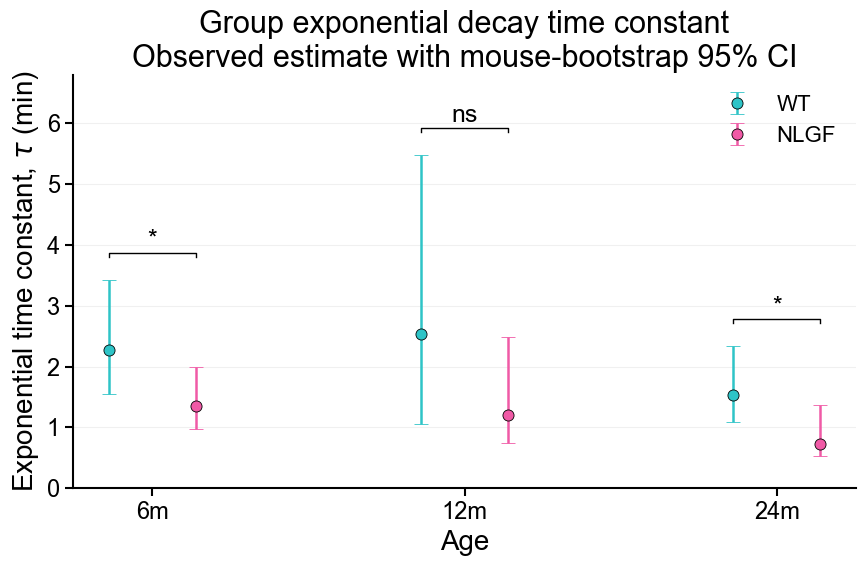

Saved tau figure to:
/Volumes/Aimi_SmrtKg/Tmaze_MASTER_all_cohorts/MASTER_group_tau_WT_vs_NLGF_bootstrap_CI.pdf


In [15]:

# ==========================================================
# BOOTSTRAP STATISTICAL COMPARISON OF GROUP TAU CONSTANTS
# tau = 1 / k from y = A * exp(-k*x) + C
# ==========================================================

from scipy.optimize import curve_fit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Reproducibility and precision
TAU_BOOTSTRAP_ITERATIONS = 2000
TAU_BOOTSTRAP_SEED = 20260731
rng = np.random.default_rng(TAU_BOOTSTRAP_SEED)


def significance_label(p_value):
    if pd.isna(p_value):
        return "NA"
    if p_value < 0.0001:
        return "****"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"


def fit_tau_from_group_means(group_mouse_df):
    """
    Average resampled mouse values at each ITI and fit:
        y = A * exp(-k*x) + C

    Returns tau = 1/k. NaN is returned if the fit is invalid.
    """
    summary = (
        group_mouse_df
        .groupby("ITI_midpoint_min", as_index=False, observed=True)
        .agg(mean_performance=("performance_percent", "mean"))
        .sort_values("ITI_midpoint_min")
    )

    x = summary["ITI_midpoint_min"].to_numpy(dtype=float)
    y = summary["mean_performance"].to_numpy(dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 3:
        return np.nan

    A_guess = max(float(y[0] - y[-1]), 1.0)
    C_guess = float(np.clip(y[-1], 0, 100))
    k_guess = 0.2

    try:
        parameters, _ = curve_fit(
            exp_decay,
            x,
            y,
            p0=[A_guess, k_guess, C_guess],
            # A >= 0, k > 0 and a plausible performance asymptote
            bounds=([0.0, 1e-6, 0.0], [200.0, 20.0, 100.0]),
            maxfev=50000,
        )

        _, k_fit, _ = parameters

        if not np.isfinite(k_fit) or k_fit <= 0:
            return np.nan

        tau = 1.0 / k_fit

        # Reject extreme unstable fits.
        if not np.isfinite(tau) or tau <= 0 or tau > 100:
            return np.nan

        return float(tau)

    except Exception:
        return np.nan


def bootstrap_tau_for_group(group_mouse_df, n_boot, random_generator):
    """
    Resample complete mice with replacement and refit the group curve.
    """
    mice = group_mouse_df["mouse_global"].dropna().unique()

    if len(mice) < 2:
        return np.array([], dtype=float)

    bootstrap_tau = []

    for _ in range(n_boot):
        sampled_mice = random_generator.choice(
            mice,
            size=len(mice),
            replace=True,
        )

        # Preserve duplicate resampled mice as separate bootstrap units.
        sampled_parts = []

        for bootstrap_id, mouse_id in enumerate(sampled_mice):
            mouse_rows = group_mouse_df[
                group_mouse_df["mouse_global"] == mouse_id
            ].copy()
            mouse_rows["bootstrap_mouse_id"] = bootstrap_id
            sampled_parts.append(mouse_rows)

        sampled_df = pd.concat(sampled_parts, ignore_index=True)

        tau = fit_tau_from_group_means(sampled_df)

        if np.isfinite(tau):
            bootstrap_tau.append(tau)

    return np.asarray(bootstrap_tau, dtype=float)


# ----------------------------------------------------------
# Run age-specific WT versus NLGF comparisons
# ----------------------------------------------------------
tau_summary_rows = []
tau_bootstrap_distributions = {}

for age in AGE_ORDER:

    age_df = mouse_decay_df[
        mouse_decay_df["age"] == age
    ].copy()

    group_boot = {}
    observed_tau = {}

    for genotype in GENO_ORDER:

        group_df = age_df[
            age_df["genotype"] == genotype
        ].copy()

        observed_tau[genotype] = fit_tau_from_group_means(group_df)

        group_boot[genotype] = bootstrap_tau_for_group(
            group_df,
            n_boot=TAU_BOOTSTRAP_ITERATIONS,
            random_generator=rng,
        )

        tau_bootstrap_distributions[(age, genotype)] = group_boot[genotype]

    wt_boot = group_boot.get("WT", np.array([]))
    nlgf_boot = group_boot.get("NLGF", np.array([]))

    # Pair bootstrap replicates by iteration where possible.
    n_valid = min(len(wt_boot), len(nlgf_boot))

    if n_valid > 0:
        wt_used = wt_boot[:n_valid]
        nlgf_used = nlgf_boot[:n_valid]

        # Positive difference means a longer tau in NLGF.
        tau_difference = nlgf_used - wt_used

        difference_mean = np.mean(tau_difference)
        difference_ci_low, difference_ci_high = np.percentile(
            tau_difference,
            [2.5, 97.5],
        )

        # Two-sided empirical bootstrap p-value for difference from zero.
        proportion_le_zero = (
            np.sum(tau_difference <= 0) + 1
        ) / (n_valid + 1)

        proportion_ge_zero = (
            np.sum(tau_difference >= 0) + 1
        ) / (n_valid + 1)

        p_value = min(
            1.0,
            2 * min(proportion_le_zero, proportion_ge_zero),
        )
    else:
        difference_mean = np.nan
        difference_ci_low = np.nan
        difference_ci_high = np.nan
        p_value = np.nan

    wt_ci = (
        np.percentile(wt_boot, [2.5, 97.5])
        if len(wt_boot) > 0
        else [np.nan, np.nan]
    )

    nlgf_ci = (
        np.percentile(nlgf_boot, [2.5, 97.5])
        if len(nlgf_boot) > 0
        else [np.nan, np.nan]
    )

    tau_summary_rows.append({
        "age": age,
        "comparison": "WT vs NLGF",
        "WT_tau_observed_min": observed_tau.get("WT", np.nan),
        "WT_tau_bootstrap_mean_min": (
            np.mean(wt_boot) if len(wt_boot) else np.nan
        ),
        "WT_tau_bootstrap_CI95_low_min": wt_ci[0],
        "WT_tau_bootstrap_CI95_high_min": wt_ci[1],
        "WT_successful_bootstrap_fits": len(wt_boot),
        "NLGF_tau_observed_min": observed_tau.get("NLGF", np.nan),
        "NLGF_tau_bootstrap_mean_min": (
            np.mean(nlgf_boot) if len(nlgf_boot) else np.nan
        ),
        "NLGF_tau_bootstrap_CI95_low_min": nlgf_ci[0],
        "NLGF_tau_bootstrap_CI95_high_min": nlgf_ci[1],
        "NLGF_successful_bootstrap_fits": len(nlgf_boot),
        "tau_difference_NLGF_minus_WT_min": difference_mean,
        "difference_CI95_low_min": difference_ci_low,
        "difference_CI95_high_min": difference_ci_high,
        "bootstrap_p_value_two_sided": p_value,
        "significance": significance_label(p_value),
        "bootstrap_iterations_requested": TAU_BOOTSTRAP_ITERATIONS,
    })


tau_statistics_df = pd.DataFrame(tau_summary_rows)

display(tau_statistics_df)

tau_statistics_path = (
    OUTPUT_DIR
    / "MASTER_group_tau_WT_vs_NLGF_bootstrap_statistics.csv"
)

tau_statistics_df.to_csv(
    tau_statistics_path,
    index=False,
)

print(f"Saved tau statistics to:\n{tau_statistics_path}")


# ----------------------------------------------------------
# Save long-form bootstrap distributions
# ----------------------------------------------------------
bootstrap_long_rows = []

for (age, genotype), distribution in tau_bootstrap_distributions.items():
    for bootstrap_index, tau_value in enumerate(distribution):
        bootstrap_long_rows.append({
            "age": age,
            "genotype": genotype,
            "bootstrap_iteration": bootstrap_index + 1,
            "tau_exp_min": tau_value,
        })

tau_bootstrap_long_df = pd.DataFrame(bootstrap_long_rows)

tau_bootstrap_long_path = (
    OUTPUT_DIR
    / "MASTER_group_tau_bootstrap_distributions.csv"
)

tau_bootstrap_long_df.to_csv(
    tau_bootstrap_long_path,
    index=False,
)


# ----------------------------------------------------------
# Plot observed tau with bootstrap 95% confidence intervals
# ----------------------------------------------------------
fig_tau, ax_tau = plt.subplots(figsize=(9, 6))

age_x = np.arange(len(AGE_ORDER), dtype=float)
width = 0.28

for genotype_index, genotype in enumerate(GENO_ORDER):

    offset = (
        genotype_index - (len(GENO_ORDER) - 1) / 2
    ) * width

    x_positions = age_x + offset

    observed_values = []
    lower_errors = []
    upper_errors = []

    for age in AGE_ORDER:
        row = tau_statistics_df[
            tau_statistics_df["age"] == age
        ].iloc[0]

        observed = row[f"{genotype}_tau_observed_min"]
        ci_low = row[f"{genotype}_tau_bootstrap_CI95_low_min"]
        ci_high = row[f"{genotype}_tau_bootstrap_CI95_high_min"]

        observed_values.append(observed)
        lower_errors.append(observed - ci_low)
        upper_errors.append(ci_high - observed)

    observed_values = np.asarray(observed_values, dtype=float)
    y_error = np.vstack([
        np.asarray(lower_errors, dtype=float),
        np.asarray(upper_errors, dtype=float),
    ])

    ax_tau.errorbar(
        x_positions,
        observed_values,
        yerr=y_error,
        fmt="o",
        markersize=8,
        capsize=5,
        linewidth=1.8,
        color=GENO_COLORS[genotype],
        markeredgecolor="black",
        markeredgewidth=0.6,
        label=genotype,
        zorder=3,
    )


# Significance labels for WT versus NLGF within each age
finite_tau_values = []

for genotype in GENO_ORDER:
    finite_tau_values.extend(
        tau_statistics_df[
            f"{genotype}_tau_bootstrap_CI95_high_min"
        ].dropna().tolist()
    )

base_height = max(finite_tau_values) if finite_tau_values else 1.0
annotation_step = max(base_height * 0.08, 0.25)

for age_index, age in enumerate(AGE_ORDER):

    row = tau_statistics_df[
        tau_statistics_df["age"] == age
    ].iloc[0]

    wt_high = row["WT_tau_bootstrap_CI95_high_min"]
    nlgf_high = row["NLGF_tau_bootstrap_CI95_high_min"]

    if not np.isfinite(wt_high) or not np.isfinite(nlgf_high):
        continue

    y_line = max(wt_high, nlgf_high) + annotation_step

    x1 = age_x[age_index] - width / 2
    x2 = age_x[age_index] + width / 2

    ax_tau.plot(
        [x1, x1, x2, x2],
        [
            y_line - annotation_step * 0.15,
            y_line,
            y_line,
            y_line - annotation_step * 0.15,
        ],
        color="black",
        linewidth=1,
    )

    ax_tau.text(
        (x1 + x2) / 2,
        y_line + annotation_step * 0.05,
        row["significance"],
        ha="center",
        va="bottom",
    )


ax_tau.set_xticks(age_x)
ax_tau.set_xticklabels(AGE_ORDER)
ax_tau.set_xlabel("Age")
ax_tau.set_ylabel(r"Exponential time constant, $\tau$ (min)")
ax_tau.set_title(
    "Group exponential decay time constant\n"
    "Observed estimate with mouse-bootstrap 95% CI"
)
ax_tau.legend(frameon=False)
ax_tau.grid(axis="y", alpha=0.18)
ax_tau.spines["top"].set_visible(False)
ax_tau.spines["right"].set_visible(False)

upper_limit = (
    max(finite_tau_values) + 3 * annotation_step
    if finite_tau_values
    else 5
)
ax_tau.set_ylim(bottom=0, top=upper_limit)

fig_tau.tight_layout()

tau_figure_path = (
    OUTPUT_DIR
    / "MASTER_group_tau_WT_vs_NLGF_bootstrap_CI.pdf"
)

fig_tau.savefig(
    tau_figure_path,
    format="pdf",
    bbox_inches="tight",
    transparent=True,
)

plt.show()

print(f"Saved tau figure to:\n{tau_figure_path}")


## Trial counts and proportion learning

This section uses the ITI bins exported by the cohort notebooks.

- Trial counts are summarised across individual mice.
- Learning proportions are shown as learned versus not learned.
- Exact binomial tests assess each genotype against 50%.
- Fisher's exact tests compare WT and NLGF learned/not-learned proportions within each age.


## Statistical tests for trial counts and side performance

The following analyses use individual mice as the statistical unit.

### Number of trials per ITI bin
- WT versus NLGF within each age and ITI bin.
- Pairwise age comparisons within each genotype and ITI bin.

### Side performance after learning
- WT versus NLGF within each age and side.
- Pairwise age comparisons within each genotype and side.
- Paired left-versus-right comparisons within each age and genotype.

Normality is assessed using Shapiro–Wilk where at least three observations are available. Welch's t-test or paired t-test is used when the relevant distributions are normal; otherwise, Mann–Whitney U or Wilcoxon signed-rank tests are used. Pairwise families are additionally reported with Holm-adjusted p-values.


In [16]:

# ==========================================================
# REUSABLE STATISTICAL HELPERS
# ==========================================================

from itertools import combinations
from scipy.stats import (
    shapiro,
    ttest_ind,
    mannwhitneyu,
    ttest_rel,
    wilcoxon,
)
import numpy as np
import pandas as pd


def _clean_numeric(values):
    return (
        pd.to_numeric(pd.Series(values), errors="coerce")
        .dropna()
        .to_numpy(dtype=float)
    )


def _normality_p(values):
    values = _clean_numeric(values)
    if len(values) < 3:
        return np.nan
    try:
        return float(shapiro(values).pvalue)
    except Exception:
        return np.nan


def _sig_label(p_value):
    if pd.isna(p_value):
        return "NA"
    if p_value < 0.0001:
        return "****"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"


def _holm_adjust(p_values):
    """
    Holm step-down adjustment without requiring statsmodels.
    NaN values remain NaN.
    """
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p_values), np.nan, dtype=float)

    valid_idx = np.where(np.isfinite(p_values))[0]
    if len(valid_idx) == 0:
        return adjusted

    valid_p = p_values[valid_idx]
    order = np.argsort(valid_p)
    sorted_p = valid_p[order]
    m = len(sorted_p)

    sorted_adjusted = np.empty(m, dtype=float)
    running_max = 0.0

    for rank, p_value in enumerate(sorted_p):
        candidate = (m - rank) * p_value
        running_max = max(running_max, candidate)
        sorted_adjusted[rank] = min(running_max, 1.0)

    unsorted_adjusted = np.empty(m, dtype=float)
    unsorted_adjusted[order] = sorted_adjusted
    adjusted[valid_idx] = unsorted_adjusted

    return adjusted


def compare_independent_groups(
    group_1,
    group_2,
    group_1_name="Group 1",
    group_2_name="Group 2",
):
    g1 = _clean_numeric(group_1)
    g2 = _clean_numeric(group_2)

    result = {
        "group_1": group_1_name,
        "group_2": group_2_name,
        "group_1_n": len(g1),
        "group_2_n": len(g2),
        "group_1_mean": np.mean(g1) if len(g1) else np.nan,
        "group_1_SD": np.std(g1, ddof=1) if len(g1) > 1 else np.nan,
        "group_2_mean": np.mean(g2) if len(g2) else np.nan,
        "group_2_SD": np.std(g2, ddof=1) if len(g2) > 1 else np.nan,
        "group_1_normality_p": _normality_p(g1),
        "group_2_normality_p": _normality_p(g2),
        "test": "Not tested",
        "statistic": np.nan,
        "p_value": np.nan,
    }

    if len(g1) < 2 or len(g2) < 2:
        result["note"] = "Fewer than two observations in at least one group"
        result["significance"] = "NA"
        return result

    g1_normal = (
        np.isfinite(result["group_1_normality_p"])
        and result["group_1_normality_p"] > 0.05
    )
    g2_normal = (
        np.isfinite(result["group_2_normality_p"])
        and result["group_2_normality_p"] > 0.05
    )

    if g1_normal and g2_normal:
        statistic, p_value = ttest_ind(
            g1,
            g2,
            equal_var=False,
            nan_policy="omit",
        )
        test_name = "Welch t-test"
    else:
        statistic, p_value = mannwhitneyu(
            g1,
            g2,
            alternative="two-sided",
        )
        test_name = "Mann-Whitney U"

    result.update({
        "test": test_name,
        "statistic": float(statistic),
        "p_value": float(p_value),
        "significance": _sig_label(p_value),
        "note": "",
    })
    return result


def compare_paired_groups(
    paired_table,
    value_1_col,
    value_2_col,
    group_1_name="Left",
    group_2_name="Right",
):
    paired = paired_table[[value_1_col, value_2_col]].copy()
    paired[value_1_col] = pd.to_numeric(
        paired[value_1_col], errors="coerce"
    )
    paired[value_2_col] = pd.to_numeric(
        paired[value_2_col], errors="coerce"
    )
    paired = paired.dropna()

    x = paired[value_1_col].to_numpy(dtype=float)
    y = paired[value_2_col].to_numpy(dtype=float)
    differences = x - y

    result = {
        "group_1": group_1_name,
        "group_2": group_2_name,
        "n_pairs": len(paired),
        "group_1_mean": np.mean(x) if len(x) else np.nan,
        "group_1_SD": np.std(x, ddof=1) if len(x) > 1 else np.nan,
        "group_2_mean": np.mean(y) if len(y) else np.nan,
        "group_2_SD": np.std(y, ddof=1) if len(y) > 1 else np.nan,
        "mean_paired_difference": (
            np.mean(differences) if len(differences) else np.nan
        ),
        "difference_normality_p": _normality_p(differences),
        "test": "Not tested",
        "statistic": np.nan,
        "p_value": np.nan,
    }

    if len(paired) < 2:
        result["note"] = "Fewer than two complete mouse pairs"
        result["significance"] = "NA"
        return result

    differences_normal = (
        np.isfinite(result["difference_normality_p"])
        and result["difference_normality_p"] > 0.05
    )

    if differences_normal:
        statistic, p_value = ttest_rel(x, y, nan_policy="omit")
        test_name = "Paired t-test"
    else:
        try:
            statistic, p_value = wilcoxon(
                x,
                y,
                alternative="two-sided",
                zero_method="wilcox",
            )
            test_name = "Wilcoxon signed-rank"
        except ValueError:
            statistic, p_value = np.nan, 1.0
            test_name = "Wilcoxon signed-rank"

    result.update({
        "test": test_name,
        "statistic": float(statistic) if np.isfinite(statistic) else np.nan,
        "p_value": float(p_value),
        "significance": _sig_label(p_value),
        "note": "",
    })
    return result


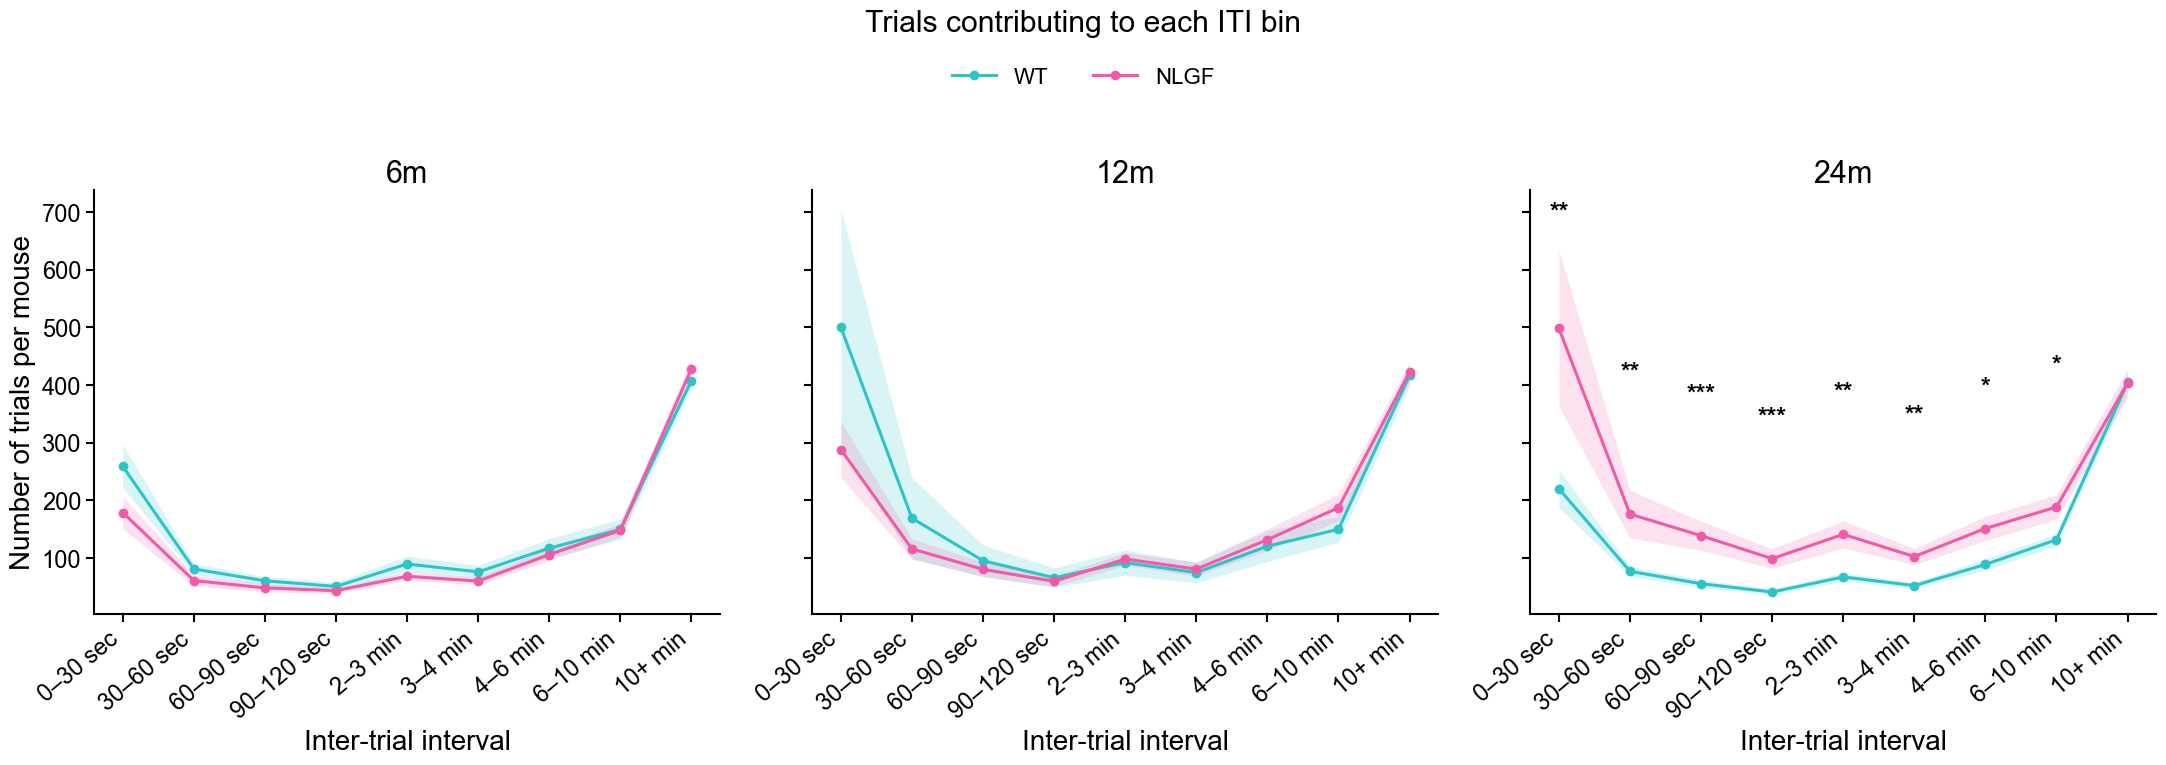

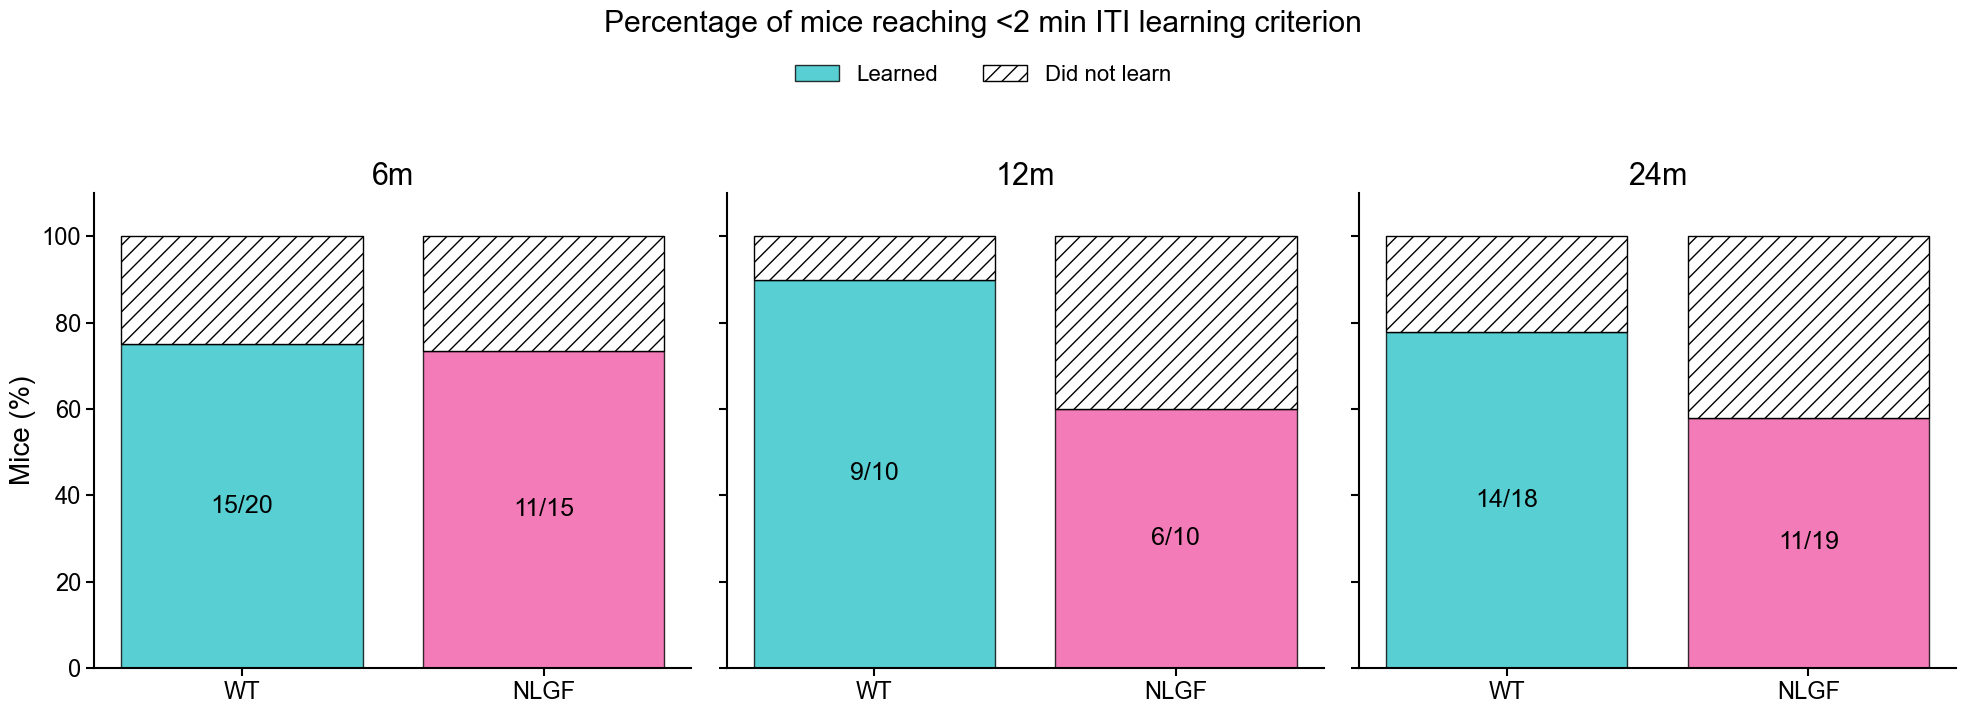

In [35]:

from scipy.stats import binomtest, fisher_exact

# ----------------------------------------------------------
# Number of trials per ITI bin
# ----------------------------------------------------------
if not iti_df.empty and "n_trials" in iti_df.columns:
    trial_count_df = iti_df[
        iti_df["genotype"].isin(GENO_ORDER)
        & iti_df["age"].isin(AGE_ORDER)
        & iti_df["ITI_bin"].isin(ITI_ORDER)
    ].copy()

    trial_count_df["n_trials"] = pd.to_numeric(
        trial_count_df["n_trials"], errors="coerce"
    )

    trial_count_summary = (
        trial_count_df
        .groupby(["age", "genotype", "ITI_bin"], observed=True, as_index=False)
        .agg(
            mean_n_trials=("n_trials", "mean"),
            sem_n_trials=("n_trials", safe_sem),
            n_mice=("mouse_global", "nunique"),
        )
    )

    fig, axes = plt.subplots(1, len(AGE_ORDER), figsize=(22, 7.5), sharey=True)
    x = np.arange(len(ITI_ORDER))

    for ax, age in zip(axes, AGE_ORDER):
        panel = trial_count_summary[trial_count_summary["age"] == age]
        for genotype in GENO_ORDER:
            group = (
                panel[panel["genotype"] == genotype]
                .set_index("ITI_bin")
                .reindex(ITI_ORDER)
            )
            y = group["mean_n_trials"].to_numpy(dtype=float)
            e = group["sem_n_trials"].to_numpy(dtype=float)
            valid = np.isfinite(y)

            ax.plot(
                x[valid], y[valid],
                marker="o", linewidth=2.2,
                color=GENO_COLORS[genotype],
                label=genotype,
            )
            sem_valid = valid & np.isfinite(e)
            if sem_valid.any():
                ax.fill_between(
                    x[sem_valid],
                    (y-e)[sem_valid],
                    (y+e)[sem_valid],
                    color=GENO_COLORS[genotype],
                    alpha=0.18,
                    linewidth=0,
                )

        # RAW WT-vs-NLGF significance stars for trial counts
        age_raw = trial_count_df[trial_count_df["age"]==age]
        from scipy.stats import shapiro, ttest_ind, mannwhitneyu
        ymax_panel = pd.to_numeric(age_raw["n_trials"],errors="coerce").max()
        span_panel = max(ymax_panel,1)
        for ii,iti in enumerate(ITI_ORDER):
            wt=age_raw.loc[(age_raw["genotype"]=="WT")&(age_raw["ITI_bin"]==iti),"n_trials"].dropna()
            ng=age_raw.loc[(age_raw["genotype"]=="NLGF")&(age_raw["ITI_bin"]==iti),"n_trials"].dropna()
            if len(wt)<2 or len(ng)<2: continue
            pw=shapiro(wt).pvalue if len(wt)>=3 else 0
            pn=shapiro(ng).pvalue if len(ng)>=3 else 0
            p=ttest_ind(wt,ng,equal_var=False).pvalue if (pw>0.05 and pn>0.05) else mannwhitneyu(wt,ng,alternative="two-sided").pvalue
            st="****" if p<0.0001 else "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
            if st:
                wt_mean = wt.mean()
                ng_mean = ng.mean()

                yy = max(wt_mean, ng_mean) + 0.08 * span_panel

                # stop stars from floating too high
                yy = min(yy, ax.get_ylim()[1] * 0.92)
                ax.text(ii,yy,st,ha="center",va="bottom",fontsize=18,fontweight="bold",clip_on=False)

        ax.set_xticks(x)
        ax.set_xticklabels(ITI_ORDER, rotation=40, ha="right")
        ax.set_title(age)
        ax.set_xlabel("Inter-trial interval")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Number of trials per mouse")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.98))
    fig.suptitle("Trials contributing to each ITI bin", y=1.03)
    fig.tight_layout(rect=[0, 0, 1, 0.94])

    fig.savefig(
        OUTPUT_DIR / "MASTER_n_trials_per_ITI_bin.pdf",
        format="pdf",
        bbox_inches="tight",
        transparent=True,
    )
    plt.show()

    trial_count_summary.to_csv(
        OUTPUT_DIR / "MASTER_n_trials_per_ITI_bin_summary.csv",
        index=False,
    )

# ----------------------------------------------------------
# Percentage learned versus not learned
# ----------------------------------------------------------
if not learning_df.empty:
    learned_df = learning_df[
        learning_df["genotype"].isin(GENO_ORDER)
        & learning_df["age"].isin(AGE_ORDER)
    ].copy()

    learned_df["criterion_met"] = (
        learned_df["criterion_met"].astype(str).str.lower()
        .isin(["true", "1", "yes"])
    )

    learned_counts = (
        learned_df.groupby(["age", "genotype"], as_index=False)
        .agg(
            learned=("criterion_met", "sum"),
            total=("criterion_met", "size"),
        )
    )
    learned_counts["not_learned"] = (
        learned_counts["total"] - learned_counts["learned"]
    )
    learned_counts["percent_learned"] = (
        100 * learned_counts["learned"] / learned_counts["total"]
    )
    learned_counts["percent_not_learned"] = (
        100 - learned_counts["percent_learned"]
    )

    stats_rows = []
    for age in AGE_ORDER:
        age_counts = learned_counts[learned_counts["age"] == age]

        fisher_odds = np.nan
        fisher_p = np.nan
        if set(GENO_ORDER).issubset(set(age_counts["genotype"])):
            indexed = age_counts.set_index("genotype")
            contingency = [
                [int(indexed.loc[g, "learned"]), int(indexed.loc[g, "not_learned"])]
                for g in GENO_ORDER
            ]
            fisher_odds, fisher_p = fisher_exact(
                contingency, alternative="two-sided"
            )

        for _, row in age_counts.iterrows():
            bt = binomtest(
                int(row["learned"]),
                int(row["total"]),
                p=0.5,
                alternative="two-sided",
            )
            stats_rows.append({
                "age": age,
                "genotype": row["genotype"],
                "n_learned": int(row["learned"]),
                "n_not_learned": int(row["not_learned"]),
                "n_total": int(row["total"]),
                "percent_learned": row["percent_learned"],
                "binomial_p_vs_50_percent": bt.pvalue,
                "WT_vs_NLGF_fisher_odds_ratio": fisher_odds,
                "WT_vs_NLGF_fisher_p": fisher_p,
            })

    learning_proportion_stats = pd.DataFrame(stats_rows)

    fig, axes = plt.subplots(1, len(AGE_ORDER), figsize=(20, 7), sharey=True)

    for ax, age in zip(axes, AGE_ORDER):
        panel = (
            learned_counts[learned_counts["age"] == age]
            .set_index("genotype")
            .reindex(GENO_ORDER)
        )
        x = np.arange(len(GENO_ORDER))

        ax.bar(
            x,
            panel["percent_learned"],
            color=[GENO_COLORS[g] for g in GENO_ORDER],
            edgecolor="black",
            alpha=0.8,
            label="Learned",
        )
        ax.bar(
            x,
            panel["percent_not_learned"],
            bottom=panel["percent_learned"],
            color="white",
            edgecolor="black",
            hatch="//",
            label="Did not learn",
        )

        for i, genotype in enumerate(GENO_ORDER):
            if genotype not in panel.index or pd.isna(panel.loc[genotype, "total"]):
                continue
            r = panel.loc[genotype]
            ax.text(
                i, r["percent_learned"]/2,
                f'{int(r["learned"])}/{int(r["total"])}',
                ha="center", va="center",
            )

        age_stats = learning_proportion_stats[
            learning_proportion_stats["age"] == age
        ]
        if not age_stats.empty:
            p = age_stats["WT_vs_NLGF_fisher_p"].iloc[0]
            sig = "****" if p < 0.0001 else "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            ax.text(0.5, 103, sig, ha="center", va="bottom")

        ax.set_xticks(x)
        ax.set_xticklabels(GENO_ORDER)
        ax.set_title(age)
        ax.set_ylim(0, 110)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Mice (%)")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.98))
    fig.suptitle("Percentage of mice reaching <2 min ITI learning criterion", y=1.03)
    fig.tight_layout(rect=[0, 0, 1, 0.93])

    fig.savefig(
        OUTPUT_DIR / "MASTER_percent_learned_not_learned.pdf",
        format="pdf",
        bbox_inches="tight",
        transparent=True,
    )
    plt.show()

    learned_counts.to_csv(
        OUTPUT_DIR / "MASTER_percent_learned_not_learned_counts.csv",
        index=False,
    )
    learning_proportion_stats.to_csv(
        OUTPUT_DIR / "MASTER_learning_proportion_statistics.csv",
        index=False,
    )


### Statistics: number of trials per ITI bin

In [18]:

# ==========================================================
# STATISTICS: NUMBER OF TRIALS PER ITI BIN
# ==========================================================

if (
    "trial_count_df" not in globals()
    or trial_count_df.empty
    or "n_trials" not in trial_count_df.columns
):
    print(
        "No mouse-level trial-count data were available. "
        "Run the trial-count analysis cell first."
    )
else:
    trial_stats_df = trial_count_df.copy()
    trial_stats_df["n_trials"] = pd.to_numeric(
        trial_stats_df["n_trials"],
        errors="coerce",
    )

    # Ensure one observation per mouse per age/genotype/ITI bin.
    trial_mouse_df = (
        trial_stats_df
        .groupby(
            ["age", "genotype", "ITI_bin", "mouse_global"],
            observed=True,
            as_index=False,
        )
        .agg(n_trials=("n_trials", "mean"))
    )

    # ------------------------------------------------------
    # WT versus NLGF within each age and ITI bin
    # ------------------------------------------------------
    trial_genotype_rows = []

    for (age, iti_bin), subset in trial_mouse_df.groupby(
        ["age", "ITI_bin"],
        observed=True,
    ):
        result = compare_independent_groups(
            subset.loc[
                subset["genotype"] == "WT",
                "n_trials",
            ],
            subset.loc[
                subset["genotype"] == "NLGF",
                "n_trials",
            ],
            group_1_name="WT",
            group_2_name="NLGF",
        )
        result.update({
            "age": age,
            "ITI_bin": iti_bin,
            "comparison": "WT vs NLGF",
        })
        trial_genotype_rows.append(result)

    trial_genotype_stats = pd.DataFrame(trial_genotype_rows)

    if not trial_genotype_stats.empty:
        trial_genotype_stats["p_holm"] = _holm_adjust(
            trial_genotype_stats["p_value"]
        )
        trial_genotype_stats["significance_holm"] = (
            trial_genotype_stats["p_holm"].apply(_sig_label)
        )

    # ------------------------------------------------------
    # Pairwise age comparisons within genotype and ITI bin
    # ------------------------------------------------------
    trial_age_rows = []

    for (genotype, iti_bin), subset in trial_mouse_df.groupby(
        ["genotype", "ITI_bin"],
        observed=True,
    ):
        family_indices = []

        for age_1, age_2 in combinations(AGE_ORDER, 2):
            result = compare_independent_groups(
                subset.loc[
                    subset["age"] == age_1,
                    "n_trials",
                ],
                subset.loc[
                    subset["age"] == age_2,
                    "n_trials",
                ],
                group_1_name=age_1,
                group_2_name=age_2,
            )
            result.update({
                "genotype": genotype,
                "ITI_bin": iti_bin,
                "age_1": age_1,
                "age_2": age_2,
                "comparison": f"{age_1} vs {age_2}",
            })
            family_indices.append(len(trial_age_rows))
            trial_age_rows.append(result)

        family_p = [
            trial_age_rows[index]["p_value"]
            for index in family_indices
        ]
        family_adjusted = _holm_adjust(family_p)

        for index, adjusted_p in zip(
            family_indices,
            family_adjusted,
        ):
            trial_age_rows[index]["p_holm"] = adjusted_p
            trial_age_rows[index]["significance_holm"] = (
                _sig_label(adjusted_p)
            )

    trial_age_stats = pd.DataFrame(trial_age_rows)

    # ------------------------------------------------------
    # Save and display
    # ------------------------------------------------------
    trial_genotype_path = (
        OUTPUT_DIR
        / "MASTER_n_trials_per_ITI_WT_vs_NLGF_statistics.csv"
    )
    trial_age_path = (
        OUTPUT_DIR
        / "MASTER_n_trials_per_ITI_age_pairwise_statistics.csv"
    )

    trial_genotype_stats.to_csv(
        trial_genotype_path,
        index=False,
    )
    trial_age_stats.to_csv(
        trial_age_path,
        index=False,
    )

    print("Number of trials: WT versus NLGF")
    display(trial_genotype_stats)

    print("Number of trials: age comparisons within genotype")
    display(trial_age_stats)

    print(f"Saved:\n{trial_genotype_path}\n{trial_age_path}")


Number of trials: WT versus NLGF


,group_1,group_2,group_1_n,group_2_n,group_1_mean,group_1_SD,group_2_mean,group_2_SD,group_1_normality_p,group_2_normality_p,test,statistic,p_value,significance,note,age,ITI_bin,comparison,p_holm,significance_holm
0,WT,NLGF,10,10,500.500000,645.233506,288.300000,153.220284,0.000020,4.399220e-01,Mann-Whitney U,57.000000,0.623176,ns,,12m,0–30 sec,WT vs NLGF,1.000000,ns
1,WT,NLGF,10,10,416.900000,56.518335,422.500000,53.494029,0.363582,1.430282e-01,Welch t-test,-0.227561,0.822560,ns,,12m,10+ min,WT vs NLGF,1.000000,ns
2,WT,NLGF,10,10,92.200000,69.350639,98.300000,34.989046,0.009848,5.127905e-02,Mann-Whitney U,31.000000,0.161972,ns,,12m,2–3 min,WT vs NLGF,1.000000,ns
3,WT,NLGF,10,10,169.100000,222.347801,115.800000,55.180109,0.000018,2.294413e-01,Mann-Whitney U,47.000000,0.850107,ns,,12m,30–60 sec,WT vs NLGF,1.000000,ns
4,WT,NLGF,10,10,74.800000,56.414734,80.900000,37.506888,0.003354,3.463051e-01,Mann-Whitney U,37.500000,0.363443,ns,,12m,3–4 min,WT vs NLGF,1.000000,ns
5,WT,NLGF,10,10,120.500000,83.536087,131.800000,58.904442,0.024351,4.569595e-01,Mann-Whitney U,37.000000,0.344704,ns,,12m,4–6 min,WT vs NLGF,1.000000,ns
6,WT,NLGF,10,10,95.400000,86.193838,80.400000,40.324241,0.000476,9.037922e-02,Mann-Whitney U,51.000000,0.969827,ns,,12m,60–90 sec,WT vs NLGF,1.000000,ns
7,WT,NLGF,10,10,149.900000,71.181224,187.400000,73.429028,0.103583,1.356787e-01,Welch t-test,-1.159564,0.261392,ns,,12m,6–10 min,WT vs NLGF,1.000000,ns
8,WT,NLGF,10,10,65.900000,53.104614,59.600000,28.296839,0.001238,3.304763e-01,Mann-Whitney U,45.000000,0.733730,ns,,12m,90–120 sec,WT vs NLGF,1.000000,ns
9,WT,NLGF,18,19,220.277778,137.618315,498.578947,589.761469,0.032131,9.844819e-07,Mann-Whitney U,79.500000,0.005683,**,,24m,0–30 sec,WT vs NLGF,0.125026,ns


Number of trials: age comparisons within genotype


,group_1,group_2,group_1_n,group_2_n,group_1_mean,group_1_SD,group_2_mean,group_2_SD,group_1_normality_p,group_2_normality_p,...,p_value,significance,note,genotype,ITI_bin,age_1,age_2,comparison,p_holm,significance_holm
0,6m,12m,15,10,178.866667,107.600363,288.300000,153.220284,0.013478,4.399220e-01,...,0.059249,ns,,NLGF,0–30 sec,6m,12m,6m vs 12m,0.118497,ns
1,6m,24m,15,19,178.866667,107.600363,498.578947,589.761469,0.013478,9.844819e-07,...,0.000984,***,,NLGF,0–30 sec,6m,24m,6m vs 24m,0.002952,**
2,12m,24m,10,19,288.300000,153.220284,498.578947,589.761469,0.439922,9.844819e-07,...,0.124180,ns,,NLGF,0–30 sec,12m,24m,12m vs 24m,0.124180,ns
3,6m,12m,15,10,428.466667,62.794298,422.500000,53.494029,0.280257,1.430282e-01,...,0.801421,ns,,NLGF,10+ min,6m,12m,6m vs 12m,1.000000,ns
4,6m,24m,15,19,428.466667,62.794298,403.526316,105.870659,0.280257,8.337594e-05,...,0.602823,ns,,NLGF,10+ min,6m,24m,6m vs 24m,1.000000,ns
5,12m,24m,10,19,422.500000,53.494029,403.526316,105.870659,0.143028,8.337594e-05,...,0.662839,ns,,NLGF,10+ min,12m,24m,12m vs 24m,1.000000,ns
6,6m,12m,15,10,68.333333,26.084113,98.300000,34.989046,0.071080,5.127905e-02,...,0.034758,*,,NLGF,2–3 min,6m,12m,6m vs 12m,0.069517,ns
7,6m,24m,15,19,68.333333,26.084113,141.157895,101.554727,0.071080,5.031080e-03,...,0.003566,**,,NLGF,2–3 min,6m,24m,6m vs 24m,0.010699,*
8,12m,24m,10,19,98.300000,34.989046,141.157895,101.554727,0.051279,5.031080e-03,...,0.241877,ns,,NLGF,2–3 min,12m,24m,12m vs 24m,0.241877,ns
9,6m,12m,15,10,60.933333,37.993358,115.800000,55.180109,0.012709,2.294413e-01,...,0.007128,**,,NLGF,30–60 sec,6m,12m,6m vs 12m,0.014256,*


Saved:
/Volumes/Aimi_SmrtKg/Tmaze_MASTER_all_cohorts/MASTER_n_trials_per_ITI_WT_vs_NLGF_statistics.csv
/Volumes/Aimi_SmrtKg/Tmaze_MASTER_all_cohorts/MASTER_n_trials_per_ITI_age_pairwise_statistics.csv


## Side performance following learning criterion

Each mouse contributes its percentage correct for left and right trials across all AC task days after its individual learning day. Mice that did not reach criterion are excluded.


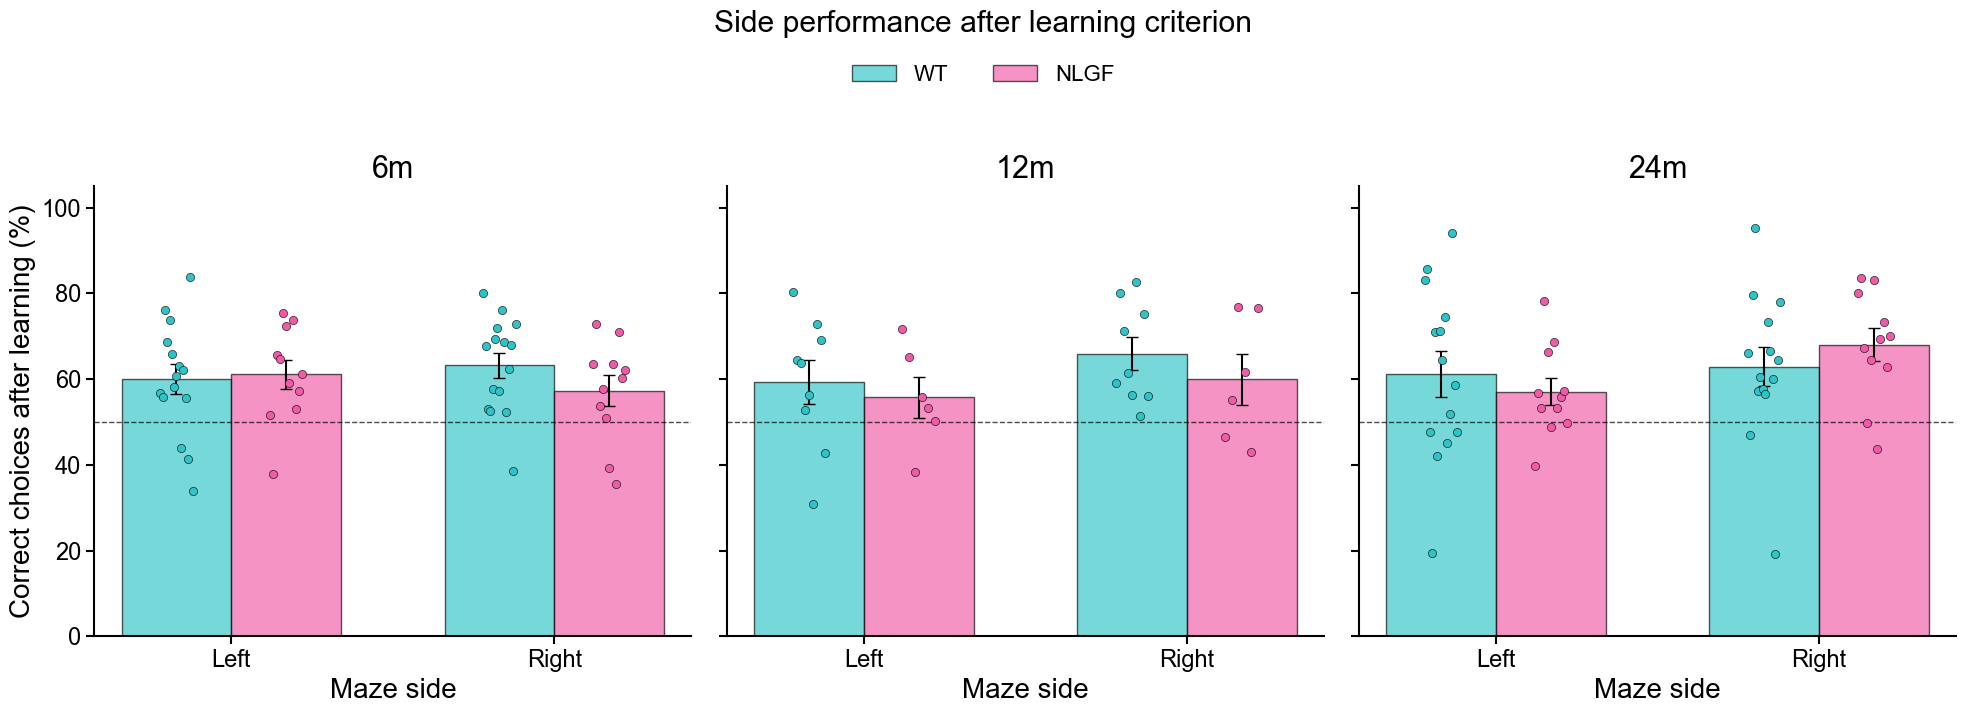

In [19]:

if "side_learning_df" not in globals() or side_learning_df.empty:
    print(
        "No side-performance files were loaded. Run the revised cohort "
        "notebooks first to create them."
    )
else:
    side_plot_df = side_learning_df[
        side_learning_df["genotype"].isin(GENO_ORDER)
        & side_learning_df["age"].isin(AGE_ORDER)
        & side_learning_df["side"].isin(["left", "right"])
    ].copy()

    side_plot_df["performance_percent"] = pd.to_numeric(
        side_plot_df["performance_percent"], errors="coerce"
    )

    side_summary = (
        side_plot_df
        .groupby(["age", "genotype", "side"], observed=True, as_index=False)
        .agg(
            mean_performance=("performance_percent", "mean"),
            sem_performance=("performance_percent", safe_sem),
            n_mice=("mouse_global", "nunique"),
            total_trials=("n_trials", "sum"),
        )
    )

    fig, axes = plt.subplots(
        1, len(AGE_ORDER), figsize=(20, 7), sharey=True
    )
    side_order = ["left", "right"]
    x = np.arange(len(side_order))
    width = 0.34

    for ax, age in zip(axes, AGE_ORDER):
        panel_summary = side_summary[side_summary["age"] == age]

        for genotype_index, genotype in enumerate(GENO_ORDER):
            group = (
                panel_summary[
                    panel_summary["genotype"] == genotype
                ]
                .set_index("side")
                .reindex(side_order)
            )
            offset = (
                genotype_index - (len(GENO_ORDER)-1)/2
            ) * width
            xpos = x + offset

            ax.bar(
                xpos,
                group["mean_performance"],
                yerr=group["sem_performance"],
                width=width,
                capsize=4,
                color=GENO_COLORS[genotype],
                edgecolor="black",
                alpha=0.65,
                label=genotype,
            )

            for side_index, side_name in enumerate(side_order):
                vals = side_plot_df.loc[
                    (side_plot_df["age"] == age)
                    & (side_plot_df["genotype"] == genotype)
                    & (side_plot_df["side"] == side_name),
                    "performance_percent",
                ].dropna()

                if vals.empty:
                    continue

                jitter = np.linspace(-0.05, 0.05, len(vals))
                ax.scatter(
                    np.full(len(vals), xpos[side_index]) + jitter,
                    vals,
                    color=GENO_COLORS[genotype],
                    edgecolor="black",
                    linewidth=0.4,
                    s=35,
                    zorder=3,
                )

        ax.axhline(
            50,
            color="black",
            linestyle="--",
            linewidth=1,
            alpha=0.7,
        )
        ax.set_xticks(x)
        ax.set_xticklabels(["Left", "Right"])
        ax.set_title(age)
        ax.set_xlabel("Maze side")
        ax.set_ylim(0, 105)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Correct choices after learning (%)")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.98))
    fig.suptitle("Side performance after learning criterion", y=1.03)
    fig.tight_layout(rect=[0, 0, 1, 0.94])

    fig.savefig(
        OUTPUT_DIR / "MASTER_side_performance_after_learning.pdf",
        format="pdf",
        bbox_inches="tight",
        transparent=True,
    )
    plt.show()

    side_plot_df.to_csv(
        OUTPUT_DIR / "MASTER_side_performance_after_learning_by_mouse.csv",
        index=False,
    )
    side_summary.to_csv(
        OUTPUT_DIR / "MASTER_side_performance_after_learning_summary.csv",
        index=False,
    )


### Statistics: side performance after learning criterion

In [20]:

# ==========================================================
# STATISTICS: SIDE PERFORMANCE AFTER LEARNING
# ==========================================================

if (
    "side_plot_df" not in globals()
    or side_plot_df.empty
    or "performance_percent" not in side_plot_df.columns
):
    print(
        "No mouse-level side-performance data were available. "
        "Run the side-performance plotting cell first."
    )
else:
    side_stats_df = side_plot_df.copy()
    side_stats_df["performance_percent"] = pd.to_numeric(
        side_stats_df["performance_percent"],
        errors="coerce",
    )

    # Ensure one value per mouse, age, genotype and side.
    side_mouse_df = (
        side_stats_df
        .groupby(
            ["age", "genotype", "side", "mouse_global"],
            observed=True,
            as_index=False,
        )
        .agg(
            performance_percent=("performance_percent", "mean"),
            n_trials=("n_trials", "sum"),
        )
    )

    # ------------------------------------------------------
    # WT versus NLGF within age and side
    # ------------------------------------------------------
    side_genotype_rows = []

    for (age, side), subset in side_mouse_df.groupby(
        ["age", "side"],
        observed=True,
    ):
        result = compare_independent_groups(
            subset.loc[
                subset["genotype"] == "WT",
                "performance_percent",
            ],
            subset.loc[
                subset["genotype"] == "NLGF",
                "performance_percent",
            ],
            group_1_name="WT",
            group_2_name="NLGF",
        )
        result.update({
            "age": age,
            "side": side,
            "comparison": "WT vs NLGF",
        })
        side_genotype_rows.append(result)

    side_genotype_stats = pd.DataFrame(side_genotype_rows)

    if not side_genotype_stats.empty:
        side_genotype_stats["p_holm"] = _holm_adjust(
            side_genotype_stats["p_value"]
        )
        side_genotype_stats["significance_holm"] = (
            side_genotype_stats["p_holm"].apply(_sig_label)
        )

    # ------------------------------------------------------
    # Pairwise age comparisons within genotype and side
    # ------------------------------------------------------
    side_age_rows = []

    for (genotype, side), subset in side_mouse_df.groupby(
        ["genotype", "side"],
        observed=True,
    ):
        family_indices = []

        for age_1, age_2 in combinations(AGE_ORDER, 2):
            result = compare_independent_groups(
                subset.loc[
                    subset["age"] == age_1,
                    "performance_percent",
                ],
                subset.loc[
                    subset["age"] == age_2,
                    "performance_percent",
                ],
                group_1_name=age_1,
                group_2_name=age_2,
            )
            result.update({
                "genotype": genotype,
                "side": side,
                "age_1": age_1,
                "age_2": age_2,
                "comparison": f"{age_1} vs {age_2}",
            })
            family_indices.append(len(side_age_rows))
            side_age_rows.append(result)

        family_p = [
            side_age_rows[index]["p_value"]
            for index in family_indices
        ]
        family_adjusted = _holm_adjust(family_p)

        for index, adjusted_p in zip(
            family_indices,
            family_adjusted,
        ):
            side_age_rows[index]["p_holm"] = adjusted_p
            side_age_rows[index]["significance_holm"] = (
                _sig_label(adjusted_p)
            )

    side_age_stats = pd.DataFrame(side_age_rows)

    # ------------------------------------------------------
    # Paired left versus right within age and genotype
    # ------------------------------------------------------
    side_paired_rows = []

    side_wide = (
        side_mouse_df
        .pivot_table(
            index=["age", "genotype", "mouse_global"],
            columns="side",
            values="performance_percent",
            aggfunc="mean",
        )
        .reset_index()
    )

    for age in AGE_ORDER:
        for genotype in GENO_ORDER:
            paired_subset = side_wide[
                side_wide["age"].eq(age)
                & side_wide["genotype"].eq(genotype)
            ].copy()

            if not {"left", "right"}.issubset(
                paired_subset.columns
            ):
                result = {
                    "group_1": "left",
                    "group_2": "right",
                    "n_pairs": 0,
                    "test": "Not tested",
                    "statistic": np.nan,
                    "p_value": np.nan,
                    "significance": "NA",
                    "note": "Left or right column absent",
                }
            else:
                result = compare_paired_groups(
                    paired_subset,
                    value_1_col="left",
                    value_2_col="right",
                    group_1_name="left",
                    group_2_name="right",
                )

            result.update({
                "age": age,
                "genotype": genotype,
                "comparison": "left vs right",
            })
            side_paired_rows.append(result)

    side_paired_stats = pd.DataFrame(side_paired_rows)

    if not side_paired_stats.empty:
        side_paired_stats["p_holm"] = _holm_adjust(
            side_paired_stats["p_value"]
        )
        side_paired_stats["significance_holm"] = (
            side_paired_stats["p_holm"].apply(_sig_label)
        )

    # ------------------------------------------------------
    # Save and display
    # ------------------------------------------------------
    side_genotype_path = (
        OUTPUT_DIR
        / "MASTER_side_after_learning_WT_vs_NLGF_statistics.csv"
    )
    side_age_path = (
        OUTPUT_DIR
        / "MASTER_side_after_learning_age_pairwise_statistics.csv"
    )
    side_paired_path = (
        OUTPUT_DIR
        / "MASTER_side_after_learning_left_vs_right_paired_statistics.csv"
    )

    side_genotype_stats.to_csv(
        side_genotype_path,
        index=False,
    )
    side_age_stats.to_csv(
        side_age_path,
        index=False,
    )
    side_paired_stats.to_csv(
        side_paired_path,
        index=False,
    )

    print("Side performance: WT versus NLGF")
    display(side_genotype_stats)

    print("Side performance: age comparisons within genotype")
    display(side_age_stats)

    print("Side performance: paired left versus right")
    display(side_paired_stats)

    print(
        "Saved:\n"
        f"{side_genotype_path}\n"
        f"{side_age_path}\n"
        f"{side_paired_path}"
    )


Side performance: WT versus NLGF


,group_1,group_2,group_1_n,group_2_n,group_1_mean,group_1_SD,group_2_mean,group_2_SD,group_1_normality_p,group_2_normality_p,test,statistic,p_value,significance,note,age,side,comparison,p_holm,significance_holm
0,WT,NLGF,9,6,59.251508,15.423894,55.818067,11.692050,0.858125,0.950278,Welch t-test,0.489409,0.632915,ns,,12m,left,WT vs NLGF,1.0,ns
1,WT,NLGF,9,6,65.909809,11.527134,59.935709,14.511478,0.308651,0.351045,Welch t-test,0.846042,0.419252,ns,,12m,right,WT vs NLGF,1.0,ns
2,WT,NLGF,14,11,61.197548,20.354581,57.087903,10.604915,0.911854,0.691027,Welch t-test,0.651279,0.522146,ns,,24m,left,WT vs NLGF,1.0,ns
3,WT,NLGF,14,11,62.951064,17.439123,67.997160,12.711439,0.262526,0.399710,Welch t-test,-0.836242,0.411657,ns,,24m,right,WT vs NLGF,1.0,ns
4,WT,NLGF,15,11,59.993055,13.348224,61.116256,11.141838,0.928918,0.644569,Welch t-test,-0.233374,0.817490,ns,,6m,left,WT vs NLGF,1.0,ns
5,WT,NLGF,15,11,63.241206,11.137590,57.334925,11.800113,0.563190,0.425274,Welch t-test,1.291067,0.210747,ns,,6m,right,WT vs NLGF,1.0,ns


Side performance: age comparisons within genotype


,group_1,group_2,group_1_n,group_2_n,group_1_mean,group_1_SD,group_2_mean,group_2_SD,group_1_normality_p,group_2_normality_p,...,p_value,significance,note,genotype,side,age_1,age_2,comparison,p_holm,significance_holm
0,6m,12m,11,6,61.116256,11.141838,55.818067,11.692050,0.644569,0.950278,...,0.385473,ns,,NLGF,left,6m,12m,6m vs 12m,1.000000,ns
1,6m,24m,11,11,61.116256,11.141838,57.087903,10.604915,0.644569,0.691027,...,0.395403,ns,,NLGF,left,6m,24m,6m vs 24m,1.000000,ns
2,12m,24m,6,11,55.818067,11.692050,57.087903,10.604915,0.950278,0.691027,...,0.829736,ns,,NLGF,left,12m,24m,12m vs 24m,1.000000,ns
3,6m,12m,11,6,57.334925,11.800113,59.935709,14.511478,0.425274,0.351045,...,0.715679,ns,,NLGF,right,6m,12m,6m vs 12m,0.715679,ns
4,6m,24m,11,11,57.334925,11.800113,67.997160,12.711439,0.425274,0.399710,...,0.054977,ns,,NLGF,right,6m,24m,6m vs 24m,0.164930,ns
5,12m,24m,6,11,59.935709,14.511478,67.997160,12.711439,0.351045,0.399710,...,0.281951,ns,,NLGF,right,12m,24m,12m vs 24m,0.563902,ns
6,6m,12m,15,9,59.993055,13.348224,59.251508,15.423894,0.928918,0.858125,...,0.906220,ns,,WT,left,6m,12m,6m vs 12m,1.000000,ns
7,6m,24m,15,14,59.993055,13.348224,61.197548,20.354581,0.928918,0.911854,...,0.853330,ns,,WT,left,6m,24m,6m vs 24m,1.000000,ns
8,12m,24m,9,14,59.251508,15.423894,61.197548,20.354581,0.858125,0.911854,...,0.797492,ns,,WT,left,12m,24m,12m vs 24m,1.000000,ns
9,6m,12m,15,9,63.241206,11.137590,65.909809,11.527134,0.563190,0.308651,...,0.585643,ns,,WT,right,6m,12m,6m vs 12m,1.000000,ns


Side performance: paired left versus right


,group_1,group_2,n_pairs,group_1_mean,group_1_SD,group_2_mean,group_2_SD,mean_paired_difference,difference_normality_p,test,statistic,p_value,significance,note,age,genotype,comparison,p_holm,significance_holm
0,left,right,15,59.993055,13.348224,63.241206,11.137590,-3.248151,0.881468,Paired t-test,-0.561903,0.583067,ns,,6m,WT,left vs right,1.000000,ns
1,left,right,11,61.116256,11.141838,57.334925,11.800113,3.781330,0.933895,Paired t-test,0.565571,0.584151,ns,,6m,NLGF,left vs right,1.000000,ns
2,left,right,9,59.251508,15.423894,65.909809,11.527134,-6.658301,0.188139,Paired t-test,-0.918669,0.385129,ns,,12m,WT,left vs right,1.000000,ns
3,left,right,6,55.818067,11.692050,59.935709,14.511478,-4.117642,0.652264,Paired t-test,-0.415797,0.694802,ns,,12m,NLGF,left vs right,1.000000,ns
4,left,right,14,61.197548,20.354581,62.951064,17.439123,-1.753516,0.836176,Paired t-test,-0.184857,0.856194,ns,,24m,WT,left vs right,1.000000,ns
5,left,right,11,57.087903,10.604915,67.997160,12.711439,-10.909257,0.347849,Paired t-test,-1.638885,0.132276,ns,,24m,NLGF,left vs right,0.793653,ns


Saved:
/Volumes/Aimi_SmrtKg/Tmaze_MASTER_all_cohorts/MASTER_side_after_learning_WT_vs_NLGF_statistics.csv
/Volumes/Aimi_SmrtKg/Tmaze_MASTER_all_cohorts/MASTER_side_after_learning_age_pairwise_statistics.csv
/Volumes/Aimi_SmrtKg/Tmaze_MASTER_all_cohorts/MASTER_side_after_learning_left_vs_right_paired_statistics.csv


# FINAL statistical analysis 
This section supersedes earlier exploratory statistics. It performs normality checks, chooses parametric/non-parametric tests as appropriate, and reports **raw p-values only**.


In [ ]:
# ==========================================================
# FINAL STATISTICS HELPERS
# ==========================================================
# IMPORTANT:
# - Independent WT vs NLGF comparisons: Shapiro-Wilk per group ->
#   Welch two-tailed t-test if both groups pass, otherwise Mann-Whitney U.
# - Paired comparisons: Shapiro-Wilk on paired differences ->
#   paired t-test if normal, otherwise Wilcoxon signed-rank.
# - Age x Genotype for one-value-per-mouse outcomes: ordinary two-way ANOVA
#   using a Type III ANOVA table.
# - Repeated observations within the same mouse (period/ITI/phase/side/time):
#   mixed-effects repeated-measures model with mouse as a random intercept.

import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, ttest_rel, wilcoxon, fisher_exact
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

ALPHA_FINAL = 0.05


def _final_clean(x):
    return pd.to_numeric(pd.Series(x), errors='coerce').dropna().to_numpy(dtype=float)


def _final_shapiro(x):
    x = _final_clean(x)
    if len(x) < 3:
        return {'n': len(x), 'W': np.nan, 'p_value': np.nan, 'normal': np.nan,
                'note': 'Shapiro-Wilk requires at least 3 observations'}
    try:
        W, p = shapiro(x)
        return {'n': len(x), 'W': float(W), 'p_value': float(p),
                'normal': bool(p > ALPHA_FINAL), 'note': ''}
    except Exception as exc:
        return {'n': len(x), 'W': np.nan, 'p_value': np.nan, 'normal': np.nan,
                'note': str(exc)}


def _final_sig(p):
    if pd.isna(p): return 'NA'
    if p < 0.0001: return '****'
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'


def final_independent_test(df, value_col, group_col='Genotype', g1='WT', g2='NLGF', context=None):
    context = {} if context is None else dict(context)
    x = _final_clean(df.loc[df[group_col].eq(g1), value_col])
    y = _final_clean(df.loc[df[group_col].eq(g2), value_col])
    nx = _final_shapiro(x); ny = _final_shapiro(y)
    row = {**context, 'value_col': value_col, 'group_1': g1, 'group_2': g2,
           'n_1': len(x), 'n_2': len(y),
           'mean_1': np.mean(x) if len(x) else np.nan,
           'mean_2': np.mean(y) if len(y) else np.nan,
           'median_1': np.median(x) if len(x) else np.nan,
           'median_2': np.median(y) if len(y) else np.nan,
           'shapiro_1_W': nx['W'], 'shapiro_1_p': nx['p_value'],
           'shapiro_2_W': ny['W'], 'shapiro_2_p': ny['p_value'],
           'test': 'not tested', 'statistic': np.nan, 'p_value': np.nan}
    if len(x) < 2 or len(y) < 2:
        row['note'] = 'Fewer than 2 observations in at least one group'
        row['stars'] = 'NA'; return row
    if nx['normal'] is True and ny['normal'] is True:
        stat, p = ttest_ind(x, y, equal_var=False, alternative='two-sided')
        test = 'Welch two-tailed unpaired t-test'
    else:
        stat, p = mannwhitneyu(x, y, alternative='two-sided')
        test = 'Mann-Whitney U'
    row.update(test=test, statistic=float(stat), p_value=float(p), stars=_final_sig(p), note='')
    return row


def final_paired_test(df, subject_col, condition_col, value_col, c1, c2, context=None):
    context = {} if context is None else dict(context)
    wide = (df[df[condition_col].isin([c1, c2])]
            .pivot_table(index=subject_col, columns=condition_col, values=value_col, aggfunc='mean'))
    if c1 not in wide.columns or c2 not in wide.columns:
        return {**context, 'value_col': value_col, 'condition_1': c1, 'condition_2': c2,
                'n_pairs': 0, 'test': 'not tested', 'statistic': np.nan,
                'p_value': np.nan, 'stars': 'NA', 'note': 'Required condition missing'}
    wide = wide.dropna(subset=[c1, c2])
    x = pd.to_numeric(wide[c1], errors='coerce').to_numpy(float)
    y = pd.to_numeric(wide[c2], errors='coerce').to_numpy(float)
    d = y - x
    nd = _final_shapiro(d)
    row = {**context, 'value_col': value_col, 'condition_1': c1, 'condition_2': c2,
           'n_pairs': len(wide), 'mean_1': np.mean(x) if len(x) else np.nan,
           'mean_2': np.mean(y) if len(y) else np.nan,
           'mean_change_2_minus_1': np.mean(d) if len(d) else np.nan,
           'difference_shapiro_W': nd['W'], 'difference_shapiro_p': nd['p_value'],
           'test': 'not tested', 'statistic': np.nan, 'p_value': np.nan}
    if len(wide) < 2:
        row['stars']='NA'; row['note']='Fewer than 2 complete pairs'; return row
    if nd['normal'] is True:
        stat, p = ttest_rel(y, x, alternative='two-sided')
        test = 'Paired two-tailed t-test'
    else:
        try:
            stat, p = wilcoxon(y, x, alternative='two-sided', zero_method='wilcox')
            test = 'Wilcoxon signed-rank'
        except ValueError:
            stat, p, test = np.nan, np.nan, 'Wilcoxon unavailable'
    row.update(test=test, statistic=float(stat) if np.isfinite(stat) else np.nan,
               p_value=float(p) if np.isfinite(p) else np.nan,
               stars=_final_sig(p), note='')
    return row


def final_normality_table(df, value_col, group_cols):
    rows=[]
    for keys, sub in df.groupby(group_cols, observed=True, dropna=False):
        if not isinstance(keys, tuple): keys=(keys,)
        r=_final_shapiro(sub[value_col])
        rows.append({**dict(zip(group_cols, keys)), 'value_col': value_col, **r})
    return pd.DataFrame(rows)


def final_two_way_anova(df, value_col, age_col='Age', genotype_col='Genotype', context=None):
    context = {} if context is None else dict(context)
    d=df[[value_col, age_col, genotype_col]].copy()
    d[value_col]=pd.to_numeric(d[value_col], errors='coerce')
    d=d.dropna()
    d=d[d[genotype_col].isin(['WT','NLGF'])]
    d=d[d[age_col].isin(['6m','12m','24m'])]
    if d.empty:
        return pd.DataFrame(), pd.DataFrame()
    formula = f"Q('{value_col}') ~ C(Q('{age_col}')) * C(Q('{genotype_col}'))"
    model = smf.ols(formula, data=d).fit()
    aov = anova_lm(model, typ=3).reset_index().rename(columns={'index':'Effect', 'PR(>F)':'p_value'})
    aov['stars']=aov['p_value'].apply(_final_sig)
    for k,v in context.items(): aov[k]=v
    resid = pd.DataFrame([{**context, 'value_col': value_col, 'analysis':'two-way ANOVA residuals', **_final_shapiro(model.resid)}])
    return aov, resid


def final_mixed_repeated(df, value_col, subject_col, repeated_col,
                         age_col='Age', genotype_col='Genotype', context=None):
    context = {} if context is None else dict(context)
    cols=[value_col, subject_col, repeated_col, age_col, genotype_col]
    d=df[cols].copy()
    d[value_col]=pd.to_numeric(d[value_col], errors='coerce')
    d=d.dropna()
    d=d[d[genotype_col].isin(['WT','NLGF'])]
    d=d[d[age_col].isin(['6m','12m','24m'])]
    if d.empty:
        return pd.DataFrame(), pd.DataFrame()
    formula=(f"Q('{value_col}') ~ C(Q('{age_col}')) * C(Q('{genotype_col}')) * C(Q('{repeated_col}'))")
    try:
        fit=smf.mixedlm(formula, d, groups=d[subject_col]).fit(reml=False, method='lbfgs', maxiter=1000, disp=False)
        ci=fit.conf_int()
        terms=[]
        for term,p in fit.pvalues.items():
            if term in ('Group Var','Intercept'): continue
            terms.append({**context, 'value_col':value_col, 'term':term,
                          'coefficient':fit.params.get(term,np.nan),
                          'SE':fit.bse.get(term,np.nan),
                          'CI_low':ci.loc[term,0] if term in ci.index else np.nan,
                          'CI_high':ci.loc[term,1] if term in ci.index else np.nan,
                          'p_value':p, 'stars':_final_sig(p),
                          'model':'Mixed-effects repeated-measures model (random intercept = mouse)'})
        residual=pd.DataFrame([{**context, 'value_col':value_col, 'analysis':'mixed-model residuals', **_final_shapiro(fit.resid)}])
        return pd.DataFrame(terms), residual
    except Exception as exc:
        return pd.DataFrame([{**context,'value_col':value_col,'term':'MODEL_FAILED','p_value':np.nan,'stars':'NA','note':str(exc)}]), pd.DataFrame()

# ==========================================================
# FINAL T-MAZE STATISTICS — RAW P VALUES ONLY
# ==========================================================
FINAL_STATS_DIR = OUTPUT_DIR / 'FINAL_unadjusted_statistics'
FINAL_STATS_DIR.mkdir(exist_ok=True)

normality=[]; pairwise=[]; aovs=[]; residuals=[]; repeated=[]; repeated_resids=[]

# 1) Learning day among learners: one value per mouse -> Age x Genotype two-way ANOVA.
if 'learning_plot_df' in globals() and not learning_plot_df.empty:
    d=learning_plot_df[learning_plot_df['genotype'].isin(['WT','NLGF']) & learning_plot_df['age'].isin(['6m','12m','24m'])].copy()
    d2=d.rename(columns={'age':'Age','genotype':'Genotype'})
    normality.append(final_normality_table(d2,'learning_day_index',['Age','Genotype']).assign(Analysis='Learning day among learners'))
    for age in ['6m','12m','24m']:
        pairwise.append(final_independent_test(d2[d2['Age'].eq(age)],'learning_day_index',context={'Analysis':'Learning day among learners','Age':age,'Comparison':'WT vs NLGF'}))
    aov,resid=final_two_way_anova(d2,'learning_day_index',context={'Analysis':'Learning day among learners'})
    if not aov.empty:aovs.append(aov)
    if not resid.empty:residuals.append(resid)

# 2) Post-learning performance: ITI repeated within mouse -> mixed repeated model.
if 'post_df' in globals() and not post_df.empty:
    d=post_df[post_df['genotype'].isin(['WT','NLGF']) & post_df['age'].isin(['6m','12m','24m'])].copy().rename(columns={'age':'Age','genotype':'Genotype'})
    normality.append(final_normality_table(d,'post_learning_mean_percent',['Age','Genotype','ITI_bin']).assign(Analysis='Post-learning performance'))
    for age in ['6m','12m','24m']:
        for iti in d['ITI_bin'].dropna().unique():
            pairwise.append(final_independent_test(d[d['Age'].eq(age)&d['ITI_bin'].eq(iti)],'post_learning_mean_percent',context={'Analysis':'Post-learning performance','Age':age,'ITI_bin':iti,'Comparison':'WT vs NLGF'}))
    model,resid=final_mixed_repeated(d,'post_learning_mean_percent','mouse_global','ITI_bin',context={'Analysis':'Post-learning performance'})
    if not model.empty:repeated.append(model)
    if not resid.empty:repeated_resids.append(resid)

# 3) Trial counts by ITI: ITI repeated within mouse.
if 'trial_mouse_df' in globals() and not trial_mouse_df.empty:
    d=trial_mouse_df.rename(columns={'age':'Age','genotype':'Genotype'}).copy()
    normality.append(final_normality_table(d,'n_trials',['Age','Genotype','ITI_bin']).assign(Analysis='Trial count per ITI'))
    for age in ['6m','12m','24m']:
        for iti in d['ITI_bin'].dropna().unique():
            pairwise.append(final_independent_test(d[d['Age'].eq(age)&d['ITI_bin'].eq(iti)],'n_trials',context={'Analysis':'Trial count per ITI','Age':age,'ITI_bin':iti,'Comparison':'WT vs NLGF'}))
    model,resid=final_mixed_repeated(d,'n_trials','mouse_global','ITI_bin',context={'Analysis':'Trial count per ITI'})
    if not model.empty:repeated.append(model)
    if not resid.empty:repeated_resids.append(resid)

# 4) Side performance: side repeated within mouse.
if 'side_mouse_df' in globals() and not side_mouse_df.empty:
    d=side_mouse_df.rename(columns={'age':'Age','genotype':'Genotype'}).copy()
    normality.append(final_normality_table(d,'performance_percent',['Age','Genotype','side']).assign(Analysis='Side performance after learning'))
    for age in ['6m','12m','24m']:
        for side in ['left','right']:
            pairwise.append(final_independent_test(d[d['Age'].eq(age)&d['side'].eq(side)],'performance_percent',context={'Analysis':'Side performance after learning','Age':age,'Side':side,'Comparison':'WT vs NLGF'}))
    model,resid=final_mixed_repeated(d,'performance_percent','mouse_global','side',context={'Analysis':'Side performance after learning'})
    if not model.empty:repeated.append(model)
    if not resid.empty:repeated_resids.append(resid)

# 5) Memory span if a mouse-level dataframe is available.
for candidate in ['memory_span_df','mouse_memory_span_df','memory_span_mouse_df']:
    if candidate in globals() and isinstance(globals()[candidate],pd.DataFrame) and not globals()[candidate].empty:
        d=globals()[candidate].copy()
        age_col='Age' if 'Age' in d.columns else 'age'; geno_col='Genotype' if 'Genotype' in d.columns else 'genotype'
        value_candidates=[c for c in ['memory_span','memory_span_min','memory_span_minutes'] if c in d.columns]
        mouse_value=value_candidates[0] if value_candidates else None
        if mouse_value:
            d=d.rename(columns={age_col:'Age',geno_col:'Genotype'})
            normality.append(final_normality_table(d,mouse_value,['Age','Genotype']).assign(Analysis='Estimated memory span'))
            for age in ['6m','12m','24m']:
                pairwise.append(final_independent_test(d[d['Age'].eq(age)],mouse_value,context={'Analysis':'Estimated memory span','Age':age,'Comparison':'WT vs NLGF'}))
            aov,resid=final_two_way_anova(d,mouse_value,context={'Analysis':'Estimated memory span'})
            if not aov.empty:aovs.append(aov)
            if not resid.empty:residuals.append(resid)
        break

# 6) Learned vs not learned: Fisher exact within age + logistic regression Age x Genotype.
fisher_rows=[]; logistic_df=pd.DataFrame()
if 'learned_df' in globals() and not learned_df.empty:
    ld=learned_df.copy().rename(columns={'age':'Age','genotype':'Genotype'})
    if 'criterion_met' in ld.columns:
        ld['learned_binary']=ld['criterion_met'].astype(str).str.lower().isin(['true','1','yes']).astype(int)
        for age in ['6m','12m','24m']:
            sub=ld[ld['Age'].eq(age)&ld['Genotype'].isin(['WT','NLGF'])]
            tab=pd.crosstab(sub['Genotype'],sub['learned_binary']).reindex(index=['WT','NLGF'],columns=[1,0],fill_value=0)
            if tab.sum().sum() and (tab.sum(axis=1)>0).all(): odds,p=fisher_exact(tab.to_numpy(),alternative='two-sided')
            else: odds,p=np.nan,np.nan
            fisher_rows.append({'Analysis':'Reached learning criterion','Age':age,'test':'Fisher exact','odds_ratio':odds,'p_value':p,'stars':_final_sig(p),
                                'WT_learned':tab.loc['WT',1],'WT_not_learned':tab.loc['WT',0],
                                'NLGF_learned':tab.loc['NLGF',1],'NLGF_not_learned':tab.loc['NLGF',0]})
        try:
            fit=smf.glm("learned_binary ~ C(Age) * C(Genotype)",data=ld[ld['Genotype'].isin(['WT','NLGF'])],family=sm.families.Binomial()).fit()
            ci=fit.conf_int(); logistic_df=pd.DataFrame({'term':fit.params.index,'coefficient':fit.params.values,'SE':fit.bse.values,
                'CI_low':ci[0].values,'CI_high':ci[1].values,'p_value':fit.pvalues.values})
            logistic_df['stars']=logistic_df['p_value'].apply(_final_sig); logistic_df['Analysis']='Learning criterion logistic regression: Age x Genotype'
        except Exception as exc:
            logistic_df=pd.DataFrame([{'Analysis':'Learning criterion logistic regression: Age x Genotype','term':'MODEL_FAILED','p_value':np.nan,'note':str(exc)}])

normality_df=pd.concat(normality,ignore_index=True) if normality else pd.DataFrame()
pairwise_df=pd.DataFrame(pairwise)
anova_df=pd.concat(aovs,ignore_index=True) if aovs else pd.DataFrame()
residual_df=pd.concat(residuals,ignore_index=True) if residuals else pd.DataFrame()
repeated_df=pd.concat(repeated,ignore_index=True) if repeated else pd.DataFrame()
repeated_resid_df=pd.concat(repeated_resids,ignore_index=True) if repeated_resids else pd.DataFrame()

normality_df.to_csv(FINAL_STATS_DIR/'normality_Shapiro_Wilk.csv',index=False)
pairwise_df.to_csv(FINAL_STATS_DIR/'WT_vs_NLGF_unadjusted.csv',index=False)
anova_df.to_csv(FINAL_STATS_DIR/'two_way_ANOVA_Age_x_Genotype.csv',index=False)
residual_df.to_csv(FINAL_STATS_DIR/'two_way_ANOVA_residual_normality.csv',index=False)
repeated_df.to_csv(FINAL_STATS_DIR/'repeated_measures_mixed_models.csv',index=False)
repeated_resid_df.to_csv(FINAL_STATS_DIR/'repeated_model_residual_normality.csv',index=False)
pd.DataFrame(fisher_rows).to_csv(FINAL_STATS_DIR/'learning_criterion_Fisher_exact_unadjusted.csv',index=False)
logistic_df.to_csv(FINAL_STATS_DIR/'learning_criterion_logistic_Age_x_Genotype.csv',index=False)

print('FINAL RAW-P T-maze statistics saved to:',FINAL_STATS_DIR)
display(pairwise_df.head(40)); display(anova_df); display(repeated_df.head(40)); display(pd.DataFrame(fisher_rows))


/opt/anaconda3/envs/smart-kages/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


FINAL RAW-P T-maze statistics saved to: /Volumes/Aimi_SmrtKg/Tmaze_MASTER_all_cohorts/FINAL_unadjusted_statistics


,Analysis,Age,Comparison,value_col,group_1,group_2,n_1,n_2,mean_1,mean_2,...,shapiro_1_p,shapiro_2_W,shapiro_2_p,test,statistic,p_value,stars,note,ITI_bin,Side
0,Learning day among learners,6m,WT vs NLGF,learning_day_index,WT,NLGF,15,11,8.200000,6.000000,...,0.125774,0.938284,5.005432e-01,Welch two-tailed unpaired t-test,1.280148,0.212986,ns,,NaN,NaN
1,Learning day among learners,12m,WT vs NLGF,learning_day_index,WT,NLGF,9,6,6.555556,3.666667,...,0.152251,0.923372,5.299727e-01,Welch two-tailed unpaired t-test,1.656353,0.121576,ns,,NaN,NaN
2,Learning day among learners,24m,WT vs NLGF,learning_day_index,WT,NLGF,14,11,4.214286,8.545455,...,0.000377,0.817310,1.589680e-02,Mann-Whitney U,24.000000,0.003767,**,,NaN,NaN
3,Post-learning performance,6m,WT vs NLGF,post_learning_mean_percent,WT,NLGF,15,11,88.068712,85.302123,...,0.028969,0.869364,7.607513e-02,Mann-Whitney U,106.500000,0.222203,ns,,0–30 sec,NaN
4,Post-learning performance,6m,WT vs NLGF,post_learning_mean_percent,WT,NLGF,15,11,54.370370,56.979786,...,0.954357,0.906420,2.210701e-01,Welch two-tailed unpaired t-test,-0.230482,0.819946,ns,,2–3 min,NaN
5,Post-learning performance,6m,WT vs NLGF,post_learning_mean_percent,WT,NLGF,15,11,68.949365,53.910534,...,0.068987,0.947300,6.096668e-01,Welch two-tailed unpaired t-test,1.912755,0.067984,ns,,30–60 sec,NaN
6,Post-learning performance,6m,WT vs NLGF,post_learning_mean_percent,WT,NLGF,15,11,52.893057,45.202020,...,0.235387,0.977312,9.493712e-01,Welch two-tailed unpaired t-test,0.821016,0.421246,ns,,3–4 min,NaN
7,Post-learning performance,6m,WT vs NLGF,post_learning_mean_percent,WT,NLGF,15,11,56.091320,41.398837,...,0.302758,0.938689,5.052153e-01,Welch two-tailed unpaired t-test,1.379350,0.181067,ns,,60–90 sec,NaN
8,Post-learning performance,6m,WT vs NLGF,post_learning_mean_percent,WT,NLGF,15,11,64.327247,59.671717,...,0.447397,0.910369,2.463617e-01,Welch two-tailed unpaired t-test,0.474511,0.641490,ns,,90–120 sec,NaN
9,Post-learning performance,12m,WT vs NLGF,post_learning_mean_percent,WT,NLGF,9,6,90.429877,81.115846,...,0.132666,0.901783,3.845776e-01,Welch two-tailed unpaired t-test,1.499984,0.173683,ns,,0–30 sec,NaN


,Effect,sum_sq,df,F,p_value,stars,Analysis
0,Intercept,80.666667,1.0,4.226927,0.044146,*,Learning day among learners
1,C(Q('Age')),96.939394,2.0,2.539808,0.087335,ns,Learning day among learners
2,C(Q('Genotype')),30.044444,1.0,1.574326,0.214445,ns,Learning day among learners
3,C(Q('Age')):C(Q('Genotype')),175.981674,2.0,4.610713,0.013719,*,Learning day among learners
4,Residual,1145.039971,60.0,NaN,NaN,NA,Learning day among learners


,Analysis,value_col,term,coefficient,SE,CI_low,CI_high,p_value,stars,model
0,Post-learning performance,post_learning_mean_percent,C(Q('Age'))[T.24m],7.877648,10.478573,-12.659978,28.415273,0.452180,ns,Mixed-effects repeated-measures model (random ...
1,Post-learning performance,post_learning_mean_percent,C(Q('Age'))[T.6m],4.186277,10.478573,-16.351349,24.723902,0.689519,ns,Mixed-effects repeated-measures model (random ...
2,Post-learning performance,post_learning_mean_percent,C(Q('Genotype'))[T.WT],9.314031,10.881741,-12.013790,30.641851,0.392035,ns,Mixed-effects repeated-measures model (random ...
3,Post-learning performance,post_learning_mean_percent,C(Q('ITI_bin'))[T.2–3 min],-26.334100,10.984680,-47.863678,-4.804523,0.016514,*,Mixed-effects repeated-measures model (random ...
4,Post-learning performance,post_learning_mean_percent,C(Q('ITI_bin'))[T.30–60 sec],-15.256058,10.984680,-36.785636,6.273520,0.164879,ns,Mixed-effects repeated-measures model (random ...
5,Post-learning performance,post_learning_mean_percent,C(Q('ITI_bin'))[T.3–4 min],-26.627310,10.984680,-48.156888,-5.097732,0.015349,*,Mixed-effects repeated-measures model (random ...
6,Post-learning performance,post_learning_mean_percent,C(Q('ITI_bin'))[T.60–90 sec],-24.991508,10.984680,-46.521085,-3.461930,0.022899,*,Mixed-effects repeated-measures model (random ...
7,Post-learning performance,post_learning_mean_percent,C(Q('ITI_bin'))[T.90–120 sec],-32.875106,10.984680,-54.404683,-11.345528,0.002764,**,Mixed-effects repeated-measures model (random ...
8,Post-learning performance,post_learning_mean_percent,C(Q('Age'))[T.24m]:C(Q('Genotype'))[T.WT],-12.453203,13.697236,-39.299293,14.392887,0.363257,ns,Mixed-effects repeated-measures model (random ...
9,Post-learning performance,post_learning_mean_percent,C(Q('Age'))[T.6m]:C(Q('Genotype'))[T.WT],-6.547441,13.622935,-33.247903,20.153020,0.630787,ns,Mixed-effects repeated-measures model (random ...


,Analysis,Age,test,odds_ratio,p_value,stars,WT_learned,WT_not_learned,NLGF_learned,NLGF_not_learned
0,Reached learning criterion,6m,Fisher exact,1.090909,1.000000,ns,15,5,11,4
1,Reached learning criterion,12m,Fisher exact,6.000000,0.303406,ns,9,1,6,4
2,Reached learning criterion,24m,Fisher exact,2.545455,0.295296,ns,14,4,11,8
